In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sys
!{sys.executable} -m pip install tqdm

In [4]:
# =====================================================
# 4-Fold Cross-Validation using CNN-LSTM (Manual CV Control) CV4
# =====================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
import os
from datetime import datetime

# --------------------------------------------
# Base path and folds
# --------------------------------------------
base_partitioned_path = r"/content/drive/My Drive/Vibration June 2026/CNN LSTM"
num_folds = 4

# --------------------------------------------
# Helper: statistical features
# --------------------------------------------
def calculate_statistical_features(vibration_data):
    vibration_data = pd.Series(vibration_data).dropna()
    if vibration_data.empty:
        return np.array([0.0, 0.0, 0.0, 0.0])
    peak_to_peak = np.ptp(vibration_data)
    kurtosis = vibration_data.kurtosis() if len(vibration_data) > 3 else 0.0
    skewness = vibration_data.skew() if len(vibration_data) > 2 else 0.0
    variance = vibration_data.var() if len(vibration_data) > 1 else 0.0
    return np.array([peak_to_peak, kurtosis, skewness, variance])

# --------------------------------------------
# Dataset generator
# --------------------------------------------
def dataset_generator(file_list, global_max_timesteps, global_max_features):
    for f in file_list:
        try:
            df = pd.read_excel(f, skiprows=1, header=None)
            df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
            sequence_label = int(df.iloc[0, 0])
            amplitude_data = df.iloc[:, 1].astype(float)
            other_features_data = df.iloc[:, 2:4].astype(float)
            extra_features = calculate_statistical_features(amplitude_data)
            extra_features_expanded = np.tile(extra_features, (len(amplitude_data), 1))
            sample = np.hstack((amplitude_data.values.reshape(-1, 1),
                                other_features_data.values,
                                extra_features_expanded))
            # Pad/truncate
            if sample.shape[0] < global_max_timesteps:
                row_padding = np.zeros((global_max_timesteps - sample.shape[0], sample.shape[1]))
                sample = np.vstack((sample, row_padding))
            elif sample.shape[0] > global_max_timesteps:
                sample = sample[:global_max_timesteps, :]
            # Pad features if needed
            if sample.shape[1] < global_max_features:
                col_padding = np.zeros((sample.shape[0], global_max_features - sample.shape[1]))
                sample = np.hstack((sample, col_padding))
            elif sample.shape[1] > global_max_features:
                sample = sample[:, :global_max_features]
            yield sample.astype(np.float32), sequence_label
        except Exception as e:
            print(f"Error loading {f}: {e}")
            continue

def make_tf_dataset(file_list, global_max_timesteps, global_max_features, batch_size=64, shuffle=True):
    output_signature = (
        tf.TensorSpec(shape=(global_max_timesteps, global_max_features), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(
        lambda: dataset_generator(file_list, global_max_timesteps, global_max_features),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------------------------------------
# CNN-LSTM model
# --------------------------------------------
def build_model(input_shape,
                conv_filters=32,
                kernel_size=5,
                pool_size=2,
                lstm_units=64,
                dense_units=32,
                dropout_rate=0.3,
                learning_rate=1e-4):
    print("\n=== Building CNN-LSTM model ===")
    model = models.Sequential()
    model.add(Input(shape=input_shape))
    model.add(layers.Normalization())
    model.add(layers.Conv1D(conv_filters, kernel_size, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=pool_size))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.2))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --------------------------------------------
# Calibration Error helper
# --------------------------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * abs(acc_bin - conf_bin)
    return ece / len(y_true)

# --------------------------------------------
# Manual CV control
# --------------------------------------------
current_fold_index = 3  # Change 0–3 for CV1–CV4
print(f"\n=== Running CV{current_fold_index + 1} ===")

cv_splits = {
    0: {"train": ["Fold1", "Fold2", "Fold3"], "val": ["Fold4"]},
    1: {"train": ["Fold1", "Fold2", "Fold4"], "val": ["Fold3"]},
    2: {"train": ["Fold1", "Fold3", "Fold4"], "val": ["Fold2"]},
    3: {"train": ["Fold2", "Fold3", "Fold4"], "val": ["Fold1"]},
}

train_folds = cv_splits[current_fold_index]["train"]
val_folds   = cv_splits[current_fold_index]["val"]

train_files, val_files = [], []
for fold in train_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    train_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

for fold in val_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    val_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

print(f"Training folds: {train_folds}, Validation fold: {val_folds}")
print(f"Train files: {len(train_files)}, Validation files: {len(val_files)}")

# --------------------------------------------
# Determine global max timesteps/features
# --------------------------------------------
print("\n=== Determining global max timesteps/features ===")
temp_raw_data_shapes = []
for f in train_files + val_files:
    try:
        df = pd.read_excel(f, skiprows=1, header=None).apply(pd.to_numeric, errors='coerce').fillna(0)
        amplitude_data_temp = df.iloc[:, 1].astype(float)
        other_features_data_temp = df.iloc[:, 2:4].astype(float)
        extra_features_temp = calculate_statistical_features(amplitude_data_temp)
        combined_feature_count = other_features_data_temp.shape[1] + 1 + len(extra_features_temp)
        temp_raw_data_shapes.append((df.shape[0], combined_feature_count))
    except Exception as e:
        print(f"Warning: {f} shape error: {e}")
        continue

global_max_timesteps = min(max(s[0] for s in temp_raw_data_shapes), 1000)
global_max_features  = max(s[1] for s in temp_raw_data_shapes)
print(f"Global max timesteps: {global_max_timesteps}, Global max features: {global_max_features}")

# --------------------------------------------
# Build streaming datasets
# --------------------------------------------
print("\n=== Preparing streaming datasets ===")
train_ds = make_tf_dataset(train_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=True)
val_ds   = make_tf_dataset(val_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=False)

# --------------------------------------------
# Train model
# --------------------------------------------
model = build_model(input_shape=(global_max_timesteps, global_max_features))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

batch_size = 64  # keep this consistent everywhere

print("\n=== Model training started ===")
steps_per_epoch = max(1, len(train_files) // batch_size)
validation_steps = max(1, len(val_files) // batch_size)

history = model.fit(
    train_ds.repeat(),
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds.repeat(),
    validation_steps=validation_steps,
    callbacks=[early_stop]
)

print("\n=== Model training completed ===")

# --------------------------------------------
# Predictions and Evaluation
# --------------------------------------------
print("\n=== Generating predictions on validation fold ===")
y_prob = model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Collecting true labels from validation dataset ===")
y_val = np.concatenate([y.numpy() for _, y in val_ds], axis=0)

# --------------------------------------------
# Save CV4 outputs to Drive (for reuse)
# --------------------------------------------
import os
import json
import numpy as np
from datetime import datetime

save_dir = "/content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs"
os.makedirs(save_dir, exist_ok=True)

fold_tag = f"CV{current_fold_index + 1}"   # CV4 if current_fold_index=3
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1) Save raw arrays (main file you will reload later)
npz_path_latest = os.path.join(save_dir, f"{fold_tag}_latest_outputs.npz")
npz_path_versioned = os.path.join(save_dir, f"{fold_tag}_{timestamp}_outputs.npz")

np.savez_compressed(
    npz_path_latest,
    y_prob=y_prob.astype(np.float32),
    y_pred=y_pred.astype(np.int32),
    y_val=y_val.astype(np.int32)
)
np.savez_compressed(
    npz_path_versioned,
    y_prob=y_prob.astype(np.float32),
    y_pred=y_pred.astype(np.int32),
    y_val=y_val.astype(np.int32)
)

# 2) Save metadata (optional but useful)
meta = {
    "fold": fold_tag,
    "timestamp": timestamp,
    "num_samples": int(len(y_val)),
    "train_folds": train_folds,
    "val_folds": val_folds,
    "global_max_timesteps": int(global_max_timesteps),
    "global_max_features": int(global_max_features),
    "batch_size": int(batch_size)
}
meta_path_latest = os.path.join(save_dir, f"{fold_tag}_latest_metadata.json")
meta_path_versioned = os.path.join(save_dir, f"{fold_tag}_{timestamp}_metadata.json")

with open(meta_path_latest, "w") as f:
    json.dump(meta, f, indent=2)
with open(meta_path_versioned, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved latest outputs: {npz_path_latest}")
print(f"Saved versioned outputs: {npz_path_versioned}")
print(f"Saved metadata: {meta_path_latest}")

print("\n=== Computing metrics ===")
acc = accuracy_score(y_val, y_pred)

# Healthy = 0, Faulty = 1
prec_H = precision_score(y_val, y_pred, pos_label=0)
prec_F = precision_score(y_val, y_pred, pos_label=1)
rec_H  = recall_score(y_val, y_pred, pos_label=0)
rec_F  = recall_score(y_val, y_pred, pos_label=1)
f1     = f1_score(y_val, y_pred, pos_label=1)  # F1 for faulty class
brier  = brier_score_loss(y_val, y_prob)
ece    = expected_calibration_error(y_val, y_prob)

print(f"\n=== Performance for CV{current_fold_index + 1} ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Healthy=0): {prec_H:.4f}")
print(f"Precision (Faulty=1): {prec_F:.4f}")
print(f"Recall (Healthy=0): {rec_H:.4f}")
print(f"Recall (Faulty=1): {rec_F:.4f}")
print(f"F1 Score (Faulty=1): {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"ECE: {ece:.4f}")

# --------------------------------------------
# Clear session after each fold
# --------------------------------------------
print("\n=== Clearing TensorFlow session ===")
tf.keras.backend.clear_session()

# Keep these variables for calibration in Cell 3
print("\n=== Variables saved for calibration ===")
print(f"y_prob shape: {y_prob.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_pred shape: {y_pred.shape}")


=== Running CV4 ===
Training folds: ['Fold2', 'Fold3', 'Fold4'], Validation fold: ['Fold1']
Train files: 7680, Validation files: 2560

=== Determining global max timesteps/features ===
Global max timesteps: 1000, Global max features: 7

=== Preparing streaming datasets ===

=== Building CNN-LSTM model ===

=== Model training started ===
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1858s 7s/step - accuracy: 0.5329 - loss: 0.6975 - val_accuracy: 0.7309 - val_loss: 0.5755
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1542s 7s/step - accuracy: 0.6281 - loss: 0.6405 - val_accuracy: 0.9223 - val_loss: 0.4617
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1543s 7s/step - accuracy: 0.7155 - loss: 0.5705 - val_accuracy: 0.9391 - val_loss: 0.3367
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1543s 7s/step - accuracy: 0.7811 - loss: 0.4839 - val_accuracy: 0.9453 - val_loss: 0.2451
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1537s 7s/step - accuracy: 0.8270 - loss: 0.4012 - val_accuracy: 0.9453 - val_loss: 0.2047
Epoch 6/20

In [5]:
# ============================================
# CV4 Post-hoc Calibration Suite
# Methods: Temp, Isotonic, Platt, BBQ, Hybrids
# ============================================

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss, log_loss
)
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from scipy.special import logit, expit
from scipy.optimize import minimize_scalar

# -----------------------------
# Paths
# -----------------------------
save_dir = "/content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs"
fold_tag = "CV4"

npz_path = os.path.join(save_dir, f"{fold_tag}_latest_outputs.npz")
assert os.path.exists(npz_path), f"Missing file: {npz_path}"

data = np.load(npz_path)
y_prob_raw = data["y_prob"].astype(np.float64).ravel()
y_val = data["y_val"].astype(np.int32).ravel()

# Safety clipping to avoid inf logits
eps = 1e-6
y_prob_raw = np.clip(y_prob_raw, eps, 1 - eps)

print(f"Loaded {fold_tag} outputs: y_prob={y_prob_raw.shape}, y_val={y_val.shape}")

# -----------------------------
# Metrics helpers
# -----------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1]) if i < n_bins-1 else (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * np.abs(acc_bin - conf_bin)
    return ece / len(y_true)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_prob = np.clip(y_prob, eps, 1-eps)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_healthy_0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_faulty_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_healthy_0": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_faulty_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_faulty_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "brier": brier_score_loss(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=15),
        "nll": log_loss(y_true, y_prob),
    }

# -----------------------------
# Temperature Scaling
# -----------------------------
def fit_temperature(y_true, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps))

    def objective(T):
        T = max(T, 1e-3)
        p = expit(z / T)
        return log_loss(y_true, np.clip(p, eps, 1-eps))

    res = minimize_scalar(objective, bounds=(0.05, 10.0), method='bounded')
    T_opt = float(res.x)
    return T_opt

def apply_temperature(y_prob, T):
    z = logit(np.clip(y_prob, eps, 1-eps))
    return np.clip(expit(z / T), eps, 1-eps)

# -----------------------------
# Platt Scaling
# -----------------------------
def fit_platt(y_true, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps)).reshape(-1, 1)
    lr = LogisticRegression(solver="lbfgs")
    lr.fit(z, y_true)
    return lr

def apply_platt(model, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps)).reshape(-1, 1)
    return np.clip(model.predict_proba(z)[:, 1], eps, 1-eps)

# -----------------------------
# Isotonic Regression
# -----------------------------
def fit_isotonic(y_true, y_prob):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_prob, y_true)
    return iso

def apply_isotonic(model, y_prob):
    return np.clip(model.predict(y_prob), eps, 1-eps)

# -----------------------------
# BBQ (Bayesian Binning into Quantiles)
# Simple robust implementation:
# - Quantile bins
# - Beta-binomial posterior mean per bin with alpha=beta=1
# -----------------------------
class BBQCalibrator:
    def __init__(self, n_bins=20, alpha=1.0, beta=1.0):
        self.n_bins = n_bins
        self.alpha = alpha
        self.beta = beta
        self.bin_edges_ = None
        self.bin_post_mean_ = None

    def fit(self, y_prob, y_true):
        y_prob = np.asarray(y_prob)
        y_true = np.asarray(y_true)

        # Quantile edges (unique + full range guards)
        q = np.linspace(0, 1, self.n_bins + 1)
        edges = np.quantile(y_prob, q)
        edges[0] = 0.0
        edges[-1] = 1.0
        edges = np.unique(edges)
        if len(edges) < 3:
            edges = np.array([0.0, 0.5, 1.0])

        self.bin_edges_ = edges
        self.bin_post_mean_ = np.zeros(len(edges)-1, dtype=float)

        for i in range(len(edges)-1):
            lo, hi = edges[i], edges[i+1]
            if i < len(edges)-2:
                idx = (y_prob >= lo) & (y_prob < hi)
            else:
                idx = (y_prob >= lo) & (y_prob <= hi)

            n = np.sum(idx)
            k = np.sum(y_true[idx]) if n > 0 else 0.0

            # Beta posterior mean
            p_hat = (k + self.alpha) / (n + self.alpha + self.beta)
            self.bin_post_mean_[i] = p_hat

        return self

    def predict(self, y_prob):
        y_prob = np.asarray(y_prob)
        out = np.zeros_like(y_prob, dtype=float)
        edges = self.bin_edges_

        bin_ids = np.digitize(y_prob, edges[1:-1], right=False)
        out = self.bin_post_mean_[bin_ids]
        return np.clip(out, eps, 1-eps)

# -----------------------------
# OOF fitting helper to reduce overfit on same fold
# -----------------------------
def oof_calibrated_probs(y_true, y_prob, method="temperature", n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = np.zeros_like(y_prob, dtype=float)

    for tr_idx, te_idx in skf.split(y_prob.reshape(-1,1), y_true):
        yt_tr, yp_tr = y_true[tr_idx], y_prob[tr_idx]
        yp_te = y_prob[te_idx]

        if method == "temperature":
            T = fit_temperature(yt_tr, yp_tr)
            oof[te_idx] = apply_temperature(yp_te, T)

        elif method == "platt":
            m = fit_platt(yt_tr, yp_tr)
            oof[te_idx] = apply_platt(m, yp_te)

        elif method == "isotonic":
            m = fit_isotonic(yt_tr, yp_tr)
            oof[te_idx] = apply_isotonic(m, yp_te)

        elif method == "bbq":
            m = BBQCalibrator(n_bins=20, alpha=1.0, beta=1.0).fit(yp_tr, yt_tr)
            oof[te_idx] = m.predict(yp_te)

        else:
            raise ValueError(f"Unknown method: {method}")

    return np.clip(oof, eps, 1-eps)

# -----------------------------
# Run calibrations
# -----------------------------
results = {}
calibrated_outputs = {}

# Baseline
results["uncalibrated"] = compute_metrics(y_val, y_prob_raw)
calibrated_outputs["uncalibrated"] = y_prob_raw

# Single methods (OOF-style)
p_temp = oof_calibrated_probs(y_val, y_prob_raw, method="temperature")
p_iso  = oof_calibrated_probs(y_val, y_prob_raw, method="isotonic")
p_platt= oof_calibrated_probs(y_val, y_prob_raw, method="platt")
p_bbq  = oof_calibrated_probs(y_val, y_prob_raw, method="bbq")

calibrated_outputs["temperature"] = p_temp
calibrated_outputs["isotonic"] = p_iso
calibrated_outputs["platt"] = p_platt
calibrated_outputs["bbq"] = p_bbq

results["temperature"] = compute_metrics(y_val, p_temp)
results["isotonic"] = compute_metrics(y_val, p_iso)
results["platt"] = compute_metrics(y_val, p_platt)
results["bbq"] = compute_metrics(y_val, p_bbq)

# Hybrids: first method then BBQ
# (again OOF chain to reduce leakage)
p_temp_bbq = oof_calibrated_probs(y_val, p_temp, method="bbq")
p_iso_bbq  = oof_calibrated_probs(y_val, p_iso, method="bbq")
p_platt_bbq= oof_calibrated_probs(y_val, p_platt, method="bbq")

calibrated_outputs["temperature_bbq"] = p_temp_bbq
calibrated_outputs["isotonic_bbq"] = p_iso_bbq
calibrated_outputs["platt_bbq"] = p_platt_bbq

results["temperature_bbq"] = compute_metrics(y_val, p_temp_bbq)
results["isotonic_bbq"] = compute_metrics(y_val, p_iso_bbq)
results["platt_bbq"] = compute_metrics(y_val, p_platt_bbq)

# -----------------------------
# Display comparison table
# -----------------------------
df_res = pd.DataFrame(results).T
df_res = df_res[[
    "accuracy",
    "precision_healthy_0",
    "precision_faulty_1",
    "recall_healthy_0",
    "recall_faulty_1",
    "f1_faulty_1",
    "brier",
    "ece",
    "nll",
]].sort_values("ece")

print("\n=== Calibration Comparison (sorted by ECE lower is better) ===")
display(df_res.style.format("{:.4f}"))

# -----------------------------
# Save outputs
# -----------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
calib_npz_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_outputs.npz")
calib_json_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_metrics.json")
calib_csv_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_metrics.csv")

np.savez_compressed(
    calib_npz_path,
    y_val=y_val.astype(np.int32),
    y_prob_uncalibrated=y_prob_raw.astype(np.float32),
    y_prob_temperature=p_temp.astype(np.float32),
    y_prob_isotonic=p_iso.astype(np.float32),
    y_prob_platt=p_platt.astype(np.float32),
    y_prob_bbq=p_bbq.astype(np.float32),
    y_prob_temperature_bbq=p_temp_bbq.astype(np.float32),
    y_prob_isotonic_bbq=p_iso_bbq.astype(np.float32),
    y_prob_platt_bbq=p_platt_bbq.astype(np.float32),
)

with open(calib_json_path, "w") as f:
    json.dump({k: {kk: float(vv) for kk, vv in v.items()} for k, v in results.items()}, f, indent=2)

df_res.to_csv(calib_csv_path, index=True)

print(f"\nSaved calibration probs: {calib_npz_path}")
print(f"Saved calibration metrics JSON: {calib_json_path}")
print(f"Saved calibration metrics CSV: {calib_csv_path}")

Loaded CV4 outputs: y_prob=(2560,), y_val=(2560,)

=== Calibration Comparison (sorted by ECE lower is better) ===


,accuracy,precision_healthy_0,precision_faulty_1,recall_healthy_0,recall_faulty_1,f1_faulty_1,brier,ece,nll
platt_bbq,0.9559,0.9562,0.9555,0.9555,0.9563,0.9559,0.0294,0.4522,0.0918
platt,0.9539,0.9162,0.9991,0.9992,0.9086,0.9517,0.0303,0.4552,0.0991
bbq,0.9566,0.9577,0.9556,0.9555,0.9578,0.9567,0.0289,0.4566,0.0943
isotonic_bbq,0.9543,0.9539,0.9547,0.9547,0.9539,0.9543,0.0298,0.4571,0.1022
temperature_bbq,0.9543,0.9547,0.9539,0.9539,0.9547,0.9543,0.0295,0.4577,0.0958
isotonic,0.9559,0.9458,0.9664,0.9672,0.9445,0.9554,0.0281,0.4612,0.0916
temperature,0.9480,0.9059,1.0000,1.0000,0.8961,0.9452,0.0481,0.4886,0.1822
uncalibrated,0.9480,0.9059,1.0000,1.0000,0.8961,0.9452,0.0488,0.4940,0.1858



Saved calibration probs: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV4_20260626_163930_calibration_outputs.npz
Saved calibration metrics JSON: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV4_20260626_163930_calibration_metrics.json
Saved calibration metrics CSV: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV4_20260626_163930_calibration_metrics.csv


=== Calibration summary (sorted by ECE) ===
Platt + BBQ      | ECE=0.4522 | Brier=0.0294
Platt            | ECE=0.4552 | Brier=0.0303
BBQ              | ECE=0.4566 | Brier=0.0289
Isotonic + BBQ   | ECE=0.4571 | Brier=0.0298
Temp + BBQ       | ECE=0.4577 | Brier=0.0295
Isotonic         | ECE=0.4612 | Brier=0.0281
Temperature      | ECE=0.4886 | Brier=0.0481
Uncalibrated     | ECE=0.4940 | Brier=0.0488


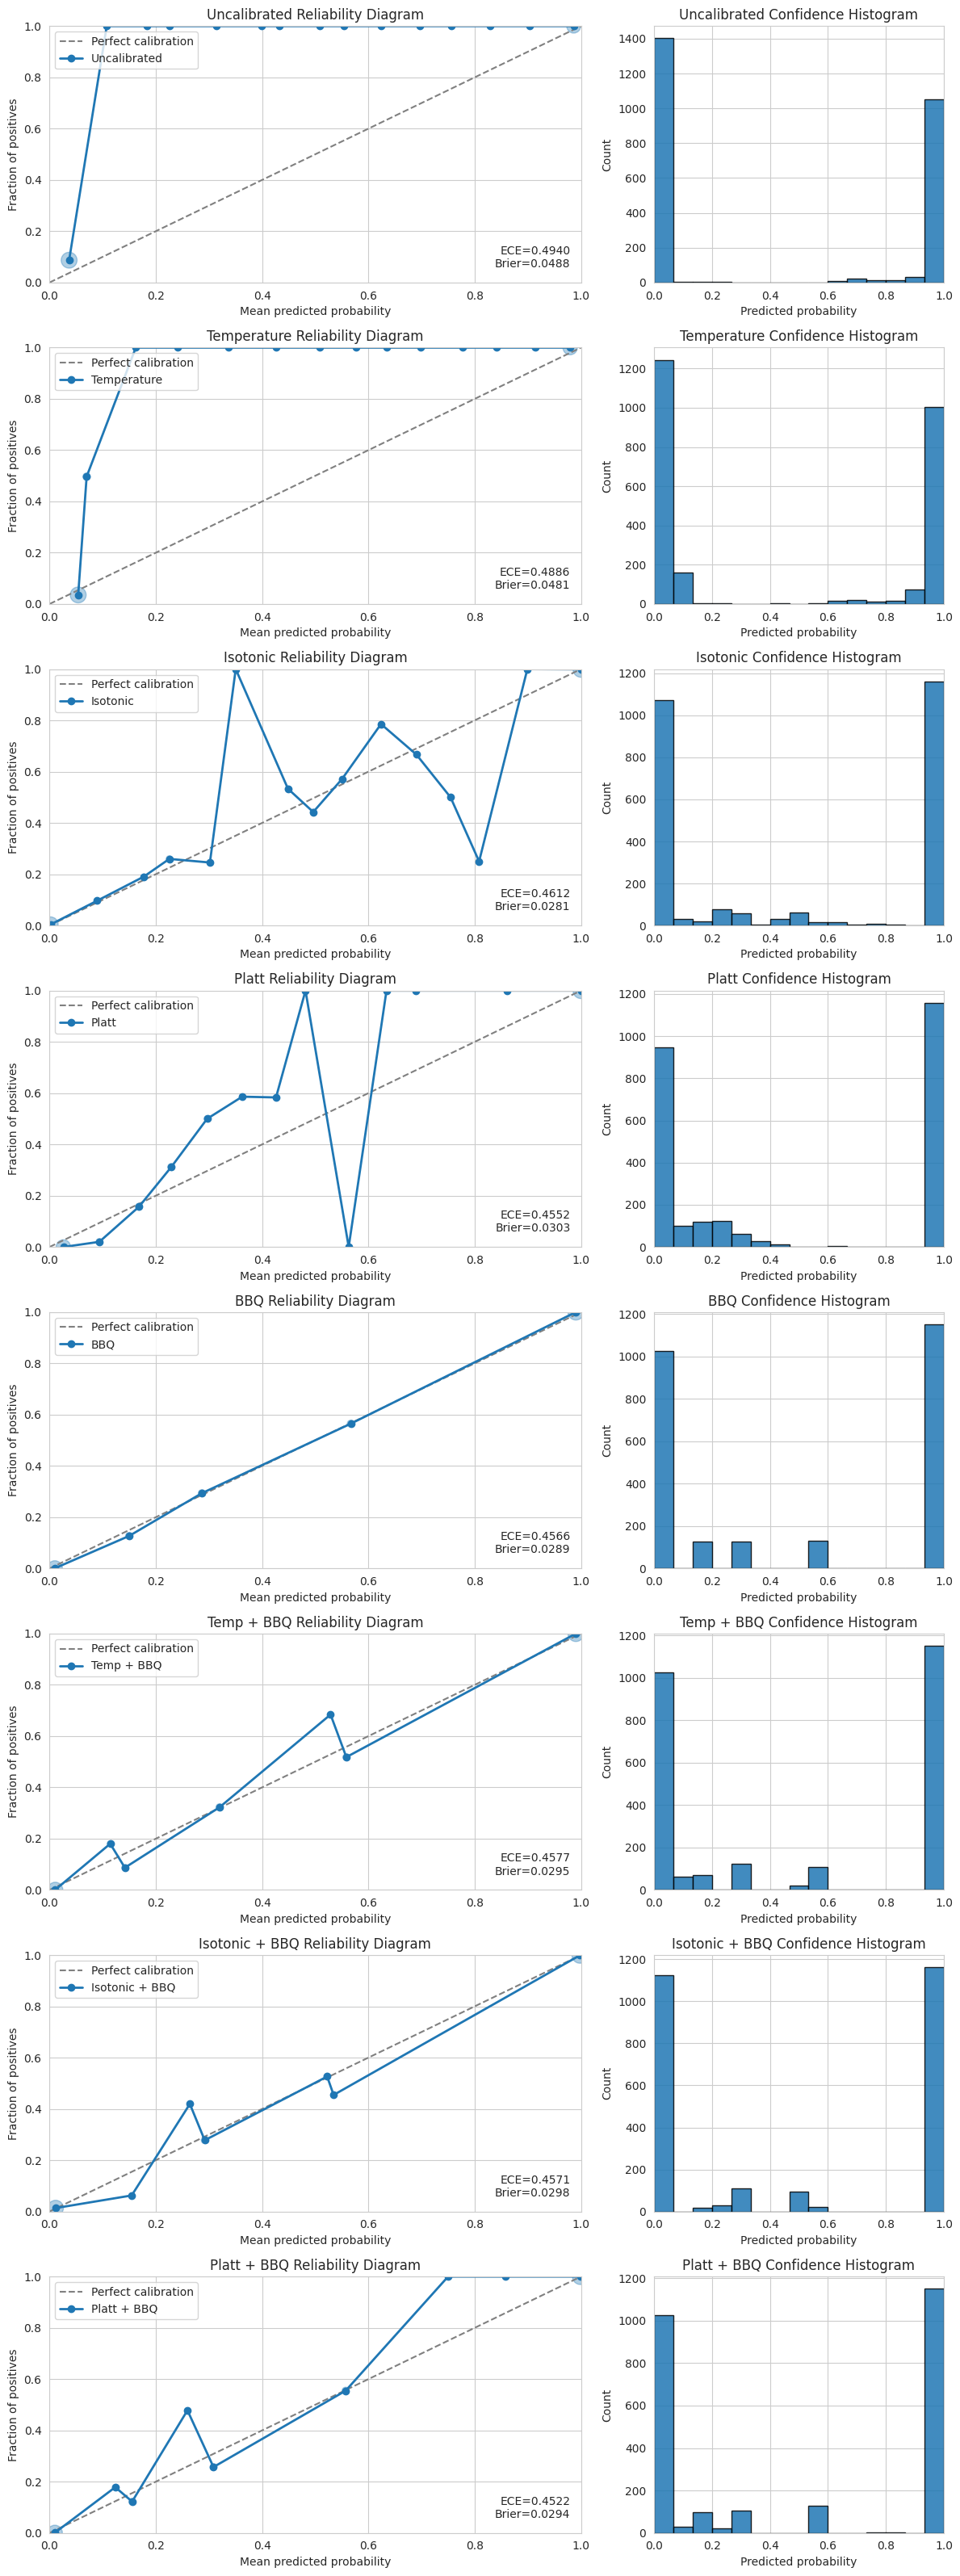

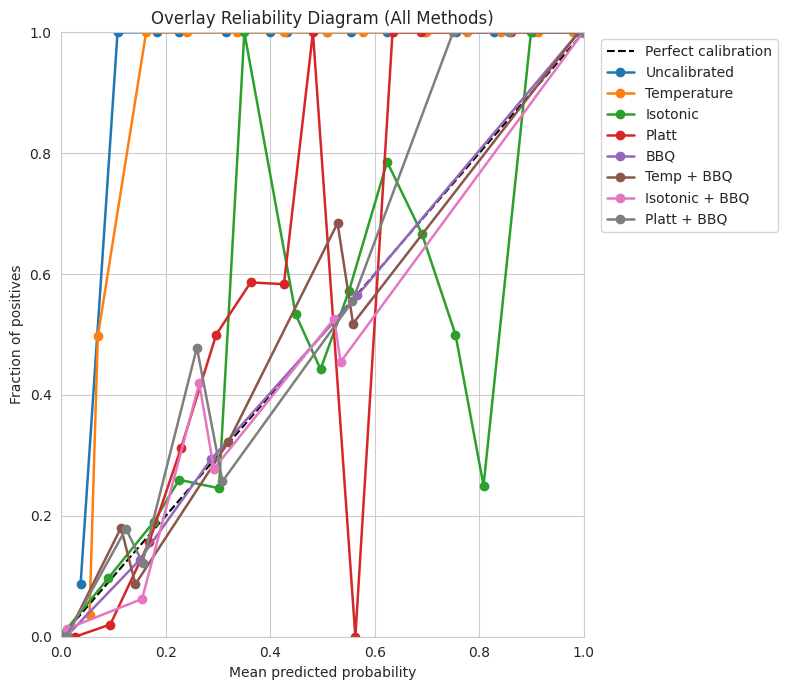

In [6]:
# ============================================
# Reliability Diagrams + Confidence Histograms
# Includes uncalibrated and all calibrated methods
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---------- Helpers ----------
def calibration_curve_manual(y_true, y_prob, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    prob_true = np.zeros(n_bins)
    prob_pred = np.zeros(n_bins)
    counts = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            idx = (y_prob >= lo) & (y_prob < hi)
        else:
            idx = (y_prob >= lo) & (y_prob <= hi)

        counts[i] = np.sum(idx)
        if counts[i] > 0:
            prob_true[i] = np.mean(y_true[idx])
            prob_pred[i] = np.mean(y_prob[idx])
        else:
            prob_true[i] = np.nan
            prob_pred[i] = np.nan

    return bin_centers, prob_true, prob_pred, counts

def expected_calibration_error(y_true, y_prob, n_bins=15):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            idx = (y_prob >= lo) & (y_prob < hi)
        else:
            idx = (y_prob >= lo) & (y_prob <= hi)

        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * np.abs(acc_bin - conf_bin)
    return ece / len(y_true)

# ---------- Collect methods ----------
# These variables are expected from your prior calibration cell:
# y_val, calibrated_outputs (dict with keys below)

required_keys = [
    "uncalibrated",
    "temperature",
    "isotonic",
    "platt",
    "bbq",
    "temperature_bbq",
    "isotonic_bbq",
    "platt_bbq",
]
for k in required_keys:
    assert k in calibrated_outputs, f"Missing key in calibrated_outputs: {k}"

method_order = [
    ("uncalibrated",      "Uncalibrated"),
    ("temperature",       "Temperature"),
    ("isotonic",          "Isotonic"),
    ("platt",             "Platt"),
    ("bbq",               "BBQ"),
    ("temperature_bbq",   "Temp + BBQ"),
    ("isotonic_bbq",      "Isotonic + BBQ"),
    ("platt_bbq",         "Platt + BBQ"),
]

# ---------- Compute summary ----------
summary = []
for key, label in method_order:
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)
    ece = expected_calibration_error(y_val, p, n_bins=15)
    brier = np.mean((p - y_val) ** 2)
    summary.append((label, ece, brier))

summary = sorted(summary, key=lambda x: x[1])  # sort by ECE
print("=== Calibration summary (sorted by ECE) ===")
for label, ece, brier in summary:
    print(f"{label:16s} | ECE={ece:.4f} | Brier={brier:.4f}")

# ---------- Plot ----------
# 8 methods x (reliability + histogram) => 8 rows, 2 cols
fig, axes = plt.subplots(
    nrows=len(method_order), ncols=2,
    figsize=(12, 4 * len(method_order)),
    gridspec_kw={"width_ratios": [2.2, 1.2]}
)

if len(method_order) == 1:
    axes = np.array([axes])  # guard for shape consistency

for r, (key, label) in enumerate(method_order):
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)

    # Reliability diagram
    ax_rel = axes[r, 0]
    centers, prob_true, prob_pred, counts = calibration_curve_manual(y_val, p, n_bins=15)
    valid = ~np.isnan(prob_true)

    ax_rel.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Perfect calibration")
    ax_rel.plot(prob_pred[valid], prob_true[valid], marker="o", linewidth=2, label=label)

    # Optional: visualize bin support as bubble size
    if np.any(valid):
        size = 20 + 180 * (counts[valid] / counts.max() if counts.max() > 0 else 1)
        ax_rel.scatter(prob_pred[valid], prob_true[valid], s=size, alpha=0.35)

    ece = expected_calibration_error(y_val, p, n_bins=15)
    brier = np.mean((p - y_val) ** 2)

    ax_rel.set_title(f"{label} Reliability Diagram")
    ax_rel.set_xlabel("Mean predicted probability")
    ax_rel.set_ylabel("Fraction of positives")
    ax_rel.set_xlim(0, 1)
    ax_rel.set_ylim(0, 1)
    ax_rel.legend(loc="upper left", frameon=True)
    ax_rel.text(
        0.98, 0.05, f"ECE={ece:.4f}\nBrier={brier:.4f}",
        transform=ax_rel.transAxes, ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    # Confidence histogram
    ax_hist = axes[r, 1]
    ax_hist.hist(p, bins=15, range=(0, 1), alpha=0.85, edgecolor="black")
    ax_hist.set_title(f"{label} Confidence Histogram")
    ax_hist.set_xlabel("Predicted probability")
    ax_hist.set_ylabel("Count")
    ax_hist.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# ---------- Optional: single combined overlay reliability plot ----------
plt.figure(figsize=(8, 7))
plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1.5, label="Perfect calibration")

for key, label in method_order:
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)
    _, prob_true, prob_pred, _ = calibration_curve_manual(y_val, p, n_bins=15)
    valid = ~np.isnan(prob_true)
    plt.plot(prob_pred[valid], prob_true[valid], marker="o", linewidth=1.8, label=label)

plt.title("Overlay Reliability Diagram (All Methods)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [8]:
# =====================================================
# 4-Fold Cross-Validation using CNN-LSTM (Manual CV Control) CV1
# =====================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
import os
from datetime import datetime

# --------------------------------------------
# Base path and folds
# --------------------------------------------
base_partitioned_path = r"/content/drive/My Drive/Vibration June 2026/CNN LSTM"
num_folds = 4

# --------------------------------------------
# Helper: statistical features
# --------------------------------------------
def calculate_statistical_features(vibration_data):
    vibration_data = pd.Series(vibration_data).dropna()
    if vibration_data.empty:
        return np.array([0.0, 0.0, 0.0, 0.0])
    peak_to_peak = np.ptp(vibration_data)
    kurtosis = vibration_data.kurtosis() if len(vibration_data) > 3 else 0.0
    skewness = vibration_data.skew() if len(vibration_data) > 2 else 0.0
    variance = vibration_data.var() if len(vibration_data) > 1 else 0.0
    return np.array([peak_to_peak, kurtosis, skewness, variance])

# --------------------------------------------
# Dataset generator
# --------------------------------------------
def dataset_generator(file_list, global_max_timesteps, global_max_features):
    for f in file_list:
        try:
            df = pd.read_excel(f, skiprows=1, header=None)
            df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
            sequence_label = int(df.iloc[0, 0])
            amplitude_data = df.iloc[:, 1].astype(float)
            other_features_data = df.iloc[:, 2:4].astype(float)
            extra_features = calculate_statistical_features(amplitude_data)
            extra_features_expanded = np.tile(extra_features, (len(amplitude_data), 1))
            sample = np.hstack((amplitude_data.values.reshape(-1, 1),
                                other_features_data.values,
                                extra_features_expanded))
            # Pad/truncate
            if sample.shape[0] < global_max_timesteps:
                row_padding = np.zeros((global_max_timesteps - sample.shape[0], sample.shape[1]))
                sample = np.vstack((sample, row_padding))
            elif sample.shape[0] > global_max_timesteps:
                sample = sample[:global_max_timesteps, :]
            # Pad features if needed
            if sample.shape[1] < global_max_features:
                col_padding = np.zeros((sample.shape[0], global_max_features - sample.shape[1]))
                sample = np.hstack((sample, col_padding))
            elif sample.shape[1] > global_max_features:
                sample = sample[:, :global_max_features]
            yield sample.astype(np.float32), sequence_label
        except Exception as e:
            print(f"Error loading {f}: {e}")
            continue

def make_tf_dataset(file_list, global_max_timesteps, global_max_features, batch_size=64, shuffle=True):
    output_signature = (
        tf.TensorSpec(shape=(global_max_timesteps, global_max_features), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(
        lambda: dataset_generator(file_list, global_max_timesteps, global_max_features),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------------------------------------
# CNN-LSTM model
# --------------------------------------------
def build_model(input_shape,
                conv_filters=32,
                kernel_size=5,
                pool_size=2,
                lstm_units=64,
                dense_units=32,
                dropout_rate=0.3,
                learning_rate=1e-4):
    print("\n=== Building CNN-LSTM model ===")
    model = models.Sequential()
    model.add(Input(shape=input_shape))
    model.add(layers.Normalization())
    model.add(layers.Conv1D(conv_filters, kernel_size, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=pool_size))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.2))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --------------------------------------------
# Calibration Error helper
# --------------------------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * abs(acc_bin - conf_bin)
    return ece / len(y_true)

# --------------------------------------------
# Manual CV control
# --------------------------------------------
current_fold_index = 0  # Change 0–3 for CV1–CV4
print(f"\n=== Running CV{current_fold_index + 1} ===")

cv_splits = {
    0: {"train": ["Fold1", "Fold2", "Fold3"], "val": ["Fold4"]},
    1: {"train": ["Fold1", "Fold2", "Fold4"], "val": ["Fold3"]},
    2: {"train": ["Fold1", "Fold3", "Fold4"], "val": ["Fold2"]},
    3: {"train": ["Fold2", "Fold3", "Fold4"], "val": ["Fold1"]},
}

train_folds = cv_splits[current_fold_index]["train"]
val_folds   = cv_splits[current_fold_index]["val"]

train_files, val_files = [], []
for fold in train_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    train_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

for fold in val_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    val_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

print(f"Training folds: {train_folds}, Validation fold: {val_folds}")
print(f"Train files: {len(train_files)}, Validation files: {len(val_files)}")

# --------------------------------------------
# Determine global max timesteps/features
# --------------------------------------------
print("\n=== Determining global max timesteps/features ===")
temp_raw_data_shapes = []
for f in train_files + val_files:
    try:
        df = pd.read_excel(f, skiprows=1, header=None).apply(pd.to_numeric, errors='coerce').fillna(0)
        amplitude_data_temp = df.iloc[:, 1].astype(float)
        other_features_data_temp = df.iloc[:, 2:4].astype(float)
        extra_features_temp = calculate_statistical_features(amplitude_data_temp)
        combined_feature_count = other_features_data_temp.shape[1] + 1 + len(extra_features_temp)
        temp_raw_data_shapes.append((df.shape[0], combined_feature_count))
    except Exception as e:
        print(f"Warning: {f} shape error: {e}")
        continue

global_max_timesteps = min(max(s[0] for s in temp_raw_data_shapes), 1000)
global_max_features  = max(s[1] for s in temp_raw_data_shapes)
print(f"Global max timesteps: {global_max_timesteps}, Global max features: {global_max_features}")

# --------------------------------------------
# Build streaming datasets
# --------------------------------------------
print("\n=== Preparing streaming datasets ===")
train_ds = make_tf_dataset(train_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=True)
val_ds   = make_tf_dataset(val_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=False)

# --------------------------------------------
# Train model
# --------------------------------------------
model = build_model(input_shape=(global_max_timesteps, global_max_features))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

batch_size = 64  # keep this consistent everywhere

print("\n=== Model training started ===")
steps_per_epoch = max(1, len(train_files) // batch_size)
validation_steps = max(1, len(val_files) // batch_size)

history = model.fit(
    train_ds.repeat(),
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds.repeat(),
    validation_steps=validation_steps,
    callbacks=[early_stop]
)

print("\n=== Model training completed ===")

# --------------------------------------------
# Predictions and Evaluation
# --------------------------------------------
print("\n=== Generating predictions on validation fold ===")
y_prob = model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Collecting true labels from validation dataset ===")
y_val = np.concatenate([y.numpy() for _, y in val_ds], axis=0)

# --------------------------------------------
# Save CV4 outputs to Drive (for reuse)
# --------------------------------------------
import os
import json
import numpy as np
from datetime import datetime

save_dir = "/content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs"
os.makedirs(save_dir, exist_ok=True)

fold_tag = f"CV{current_fold_index + 1}"   # CV4 if current_fold_index=3
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1) Save raw arrays (main file you will reload later)
npz_path_latest = os.path.join(save_dir, f"{fold_tag}_latest_outputs.npz")
npz_path_versioned = os.path.join(save_dir, f"{fold_tag}_{timestamp}_outputs.npz")

np.savez_compressed(
    npz_path_latest,
    y_prob=y_prob.astype(np.float32),
    y_pred=y_pred.astype(np.int32),
    y_val=y_val.astype(np.int32)
)
np.savez_compressed(
    npz_path_versioned,
    y_prob=y_prob.astype(np.float32),
    y_pred=y_pred.astype(np.int32),
    y_val=y_val.astype(np.int32)
)

# 2) Save metadata (optional but useful)
meta = {
    "fold": fold_tag,
    "timestamp": timestamp,
    "num_samples": int(len(y_val)),
    "train_folds": train_folds,
    "val_folds": val_folds,
    "global_max_timesteps": int(global_max_timesteps),
    "global_max_features": int(global_max_features),
    "batch_size": int(batch_size)
}
meta_path_latest = os.path.join(save_dir, f"{fold_tag}_latest_metadata.json")
meta_path_versioned = os.path.join(save_dir, f"{fold_tag}_{timestamp}_metadata.json")

with open(meta_path_latest, "w") as f:
    json.dump(meta, f, indent=2)
with open(meta_path_versioned, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved latest outputs: {npz_path_latest}")
print(f"Saved versioned outputs: {npz_path_versioned}")
print(f"Saved metadata: {meta_path_latest}")

print("\n=== Computing metrics ===")
acc = accuracy_score(y_val, y_pred)

# Healthy = 0, Faulty = 1
prec_H = precision_score(y_val, y_pred, pos_label=0)
prec_F = precision_score(y_val, y_pred, pos_label=1)
rec_H  = recall_score(y_val, y_pred, pos_label=0)
rec_F  = recall_score(y_val, y_pred, pos_label=1)
f1     = f1_score(y_val, y_pred, pos_label=1)  # F1 for faulty class
brier  = brier_score_loss(y_val, y_prob)
ece    = expected_calibration_error(y_val, y_prob)

print(f"\n=== Performance for CV{current_fold_index + 1} ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Healthy=0): {prec_H:.4f}")
print(f"Precision (Faulty=1): {prec_F:.4f}")
print(f"Recall (Healthy=0): {rec_H:.4f}")
print(f"Recall (Faulty=1): {rec_F:.4f}")
print(f"F1 Score (Faulty=1): {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"ECE: {ece:.4f}")

# --------------------------------------------
# Clear session after each fold
# --------------------------------------------
print("\n=== Clearing TensorFlow session ===")
tf.keras.backend.clear_session()

# Keep these variables for calibration in Cell 3
print("\n=== Variables saved for calibration ===")
print(f"y_prob shape: {y_prob.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_pred shape: {y_pred.shape}")


=== Running CV1 ===
Training folds: ['Fold1', 'Fold2', 'Fold3'], Validation fold: ['Fold4']
Train files: 7680, Validation files: 2560

=== Determining global max timesteps/features ===
Global max timesteps: 1000, Global max features: 7

=== Preparing streaming datasets ===

=== Building CNN-LSTM model ===

=== Model training started ===
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1921s 7s/step - accuracy: 0.5221 - loss: 0.7013 - val_accuracy: 0.7488 - val_loss: 0.5888
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1574s 7s/step - accuracy: 0.6021 - loss: 0.6589 - val_accuracy: 0.7492 - val_loss: 0.5426
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1567s 7s/step - accuracy: 0.6814 - loss: 0.6034 - val_accuracy: 0.7520 - val_loss: 0.4980
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1608s 7s/step - accuracy: 0.7354 - loss: 0.5428 - val_accuracy: 0.7645 - val_loss: 0.4618
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1610s 7s/step - accuracy: 0.7738 - loss: 0.4850 - val_accuracy: 0.8000 - val_loss: 0.4272
Epoch 6/20

In [3]:
# ============================================
# CV1 Post-hoc Calibration Suite
# Methods: Temp, Isotonic, Platt, BBQ, Hybrids
# ============================================

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss, log_loss
)
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from scipy.special import logit, expit
from scipy.optimize import minimize_scalar

# -----------------------------
# Paths
# -----------------------------
save_dir = "/content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs"
fold_tag = "CV1"

npz_path = os.path.join(save_dir, f"{fold_tag}_latest_outputs.npz")
assert os.path.exists(npz_path), f"Missing file: {npz_path}"

data = np.load(npz_path)
y_prob_raw = data["y_prob"].astype(np.float64).ravel()
y_val = data["y_val"].astype(np.int32).ravel()

# Safety clipping to avoid inf logits
eps = 1e-6
y_prob_raw = np.clip(y_prob_raw, eps, 1 - eps)

print(f"Loaded {fold_tag} outputs: y_prob={y_prob_raw.shape}, y_val={y_val.shape}")

# -----------------------------
# Metrics helpers
# -----------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1]) if i < n_bins-1 else (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * np.abs(acc_bin - conf_bin)
    return ece / len(y_true)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_prob = np.clip(y_prob, eps, 1-eps)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_healthy_0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_faulty_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_healthy_0": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_faulty_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_faulty_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "brier": brier_score_loss(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=15),
        "nll": log_loss(y_true, y_prob),
    }

# -----------------------------
# Temperature Scaling
# -----------------------------
def fit_temperature(y_true, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps))

    def objective(T):
        T = max(T, 1e-3)
        p = expit(z / T)
        return log_loss(y_true, np.clip(p, eps, 1-eps))

    res = minimize_scalar(objective, bounds=(0.05, 10.0), method='bounded')
    T_opt = float(res.x)
    return T_opt

def apply_temperature(y_prob, T):
    z = logit(np.clip(y_prob, eps, 1-eps))
    return np.clip(expit(z / T), eps, 1-eps)

# -----------------------------
# Platt Scaling
# -----------------------------
def fit_platt(y_true, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps)).reshape(-1, 1)
    lr = LogisticRegression(solver="lbfgs")
    lr.fit(z, y_true)
    return lr

def apply_platt(model, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps)).reshape(-1, 1)
    return np.clip(model.predict_proba(z)[:, 1], eps, 1-eps)

# -----------------------------
# Isotonic Regression
# -----------------------------
def fit_isotonic(y_true, y_prob):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_prob, y_true)
    return iso

def apply_isotonic(model, y_prob):
    return np.clip(model.predict(y_prob), eps, 1-eps)

# -----------------------------
# BBQ (Bayesian Binning into Quantiles)
# Simple robust implementation:
# - Quantile bins
# - Beta-binomial posterior mean per bin with alpha=beta=1
# -----------------------------
class BBQCalibrator:
    def __init__(self, n_bins=20, alpha=1.0, beta=1.0):
        self.n_bins = n_bins
        self.alpha = alpha
        self.beta = beta
        self.bin_edges_ = None
        self.bin_post_mean_ = None

    def fit(self, y_prob, y_true):
        y_prob = np.asarray(y_prob)
        y_true = np.asarray(y_true)

        # Quantile edges (unique + full range guards)
        q = np.linspace(0, 1, self.n_bins + 1)
        edges = np.quantile(y_prob, q)
        edges[0] = 0.0
        edges[-1] = 1.0
        edges = np.unique(edges)
        if len(edges) < 3:
            edges = np.array([0.0, 0.5, 1.0])

        self.bin_edges_ = edges
        self.bin_post_mean_ = np.zeros(len(edges)-1, dtype=float)

        for i in range(len(edges)-1):
            lo, hi = edges[i], edges[i+1]
            if i < len(edges)-2:
                idx = (y_prob >= lo) & (y_prob < hi)
            else:
                idx = (y_prob >= lo) & (y_prob <= hi)

            n = np.sum(idx)
            k = np.sum(y_true[idx]) if n > 0 else 0.0

            # Beta posterior mean
            p_hat = (k + self.alpha) / (n + self.alpha + self.beta)
            self.bin_post_mean_[i] = p_hat

        return self

    def predict(self, y_prob):
        y_prob = np.asarray(y_prob)
        out = np.zeros_like(y_prob, dtype=float)
        edges = self.bin_edges_

        bin_ids = np.digitize(y_prob, edges[1:-1], right=False)
        out = self.bin_post_mean_[bin_ids]
        return np.clip(out, eps, 1-eps)

# -----------------------------
# OOF fitting helper to reduce overfit on same fold
# -----------------------------
def oof_calibrated_probs(y_true, y_prob, method="temperature", n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = np.zeros_like(y_prob, dtype=float)

    for tr_idx, te_idx in skf.split(y_prob.reshape(-1,1), y_true):
        yt_tr, yp_tr = y_true[tr_idx], y_prob[tr_idx]
        yp_te = y_prob[te_idx]

        if method == "temperature":
            T = fit_temperature(yt_tr, yp_tr)
            oof[te_idx] = apply_temperature(yp_te, T)

        elif method == "platt":
            m = fit_platt(yt_tr, yp_tr)
            oof[te_idx] = apply_platt(m, yp_te)

        elif method == "isotonic":
            m = fit_isotonic(yt_tr, yp_tr)
            oof[te_idx] = apply_isotonic(m, yp_te)

        elif method == "bbq":
            m = BBQCalibrator(n_bins=20, alpha=1.0, beta=1.0).fit(yp_tr, yt_tr)
            oof[te_idx] = m.predict(yp_te)

        else:
            raise ValueError(f"Unknown method: {method}")

    return np.clip(oof, eps, 1-eps)

# -----------------------------
# Run calibrations
# -----------------------------
results = {}
calibrated_outputs = {}

# Baseline
results["uncalibrated"] = compute_metrics(y_val, y_prob_raw)
calibrated_outputs["uncalibrated"] = y_prob_raw

# Single methods (OOF-style)
p_temp = oof_calibrated_probs(y_val, y_prob_raw, method="temperature")
p_iso  = oof_calibrated_probs(y_val, y_prob_raw, method="isotonic")
p_platt= oof_calibrated_probs(y_val, y_prob_raw, method="platt")
p_bbq  = oof_calibrated_probs(y_val, y_prob_raw, method="bbq")

calibrated_outputs["temperature"] = p_temp
calibrated_outputs["isotonic"] = p_iso
calibrated_outputs["platt"] = p_platt
calibrated_outputs["bbq"] = p_bbq

results["temperature"] = compute_metrics(y_val, p_temp)
results["isotonic"] = compute_metrics(y_val, p_iso)
results["platt"] = compute_metrics(y_val, p_platt)
results["bbq"] = compute_metrics(y_val, p_bbq)

# Hybrids: first method then BBQ
# (again OOF chain to reduce leakage)
p_temp_bbq = oof_calibrated_probs(y_val, p_temp, method="bbq")
p_iso_bbq  = oof_calibrated_probs(y_val, p_iso, method="bbq")
p_platt_bbq= oof_calibrated_probs(y_val, p_platt, method="bbq")

calibrated_outputs["temperature_bbq"] = p_temp_bbq
calibrated_outputs["isotonic_bbq"] = p_iso_bbq
calibrated_outputs["platt_bbq"] = p_platt_bbq

results["temperature_bbq"] = compute_metrics(y_val, p_temp_bbq)
results["isotonic_bbq"] = compute_metrics(y_val, p_iso_bbq)
results["platt_bbq"] = compute_metrics(y_val, p_platt_bbq)

# -----------------------------
# Display comparison table
# -----------------------------
df_res = pd.DataFrame(results).T
df_res = df_res[[
    "accuracy",
    "precision_healthy_0",
    "precision_faulty_1",
    "recall_healthy_0",
    "recall_faulty_1",
    "f1_faulty_1",
    "brier",
    "ece",
    "nll",
]].sort_values("ece")

print("\n=== Calibration Comparison (sorted by ECE lower is better) ===")
display(df_res.style.format("{:.4f}"))

# -----------------------------
# Save outputs
# -----------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
calib_npz_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_outputs.npz")
calib_json_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_metrics.json")
calib_csv_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_metrics.csv")

np.savez_compressed(
    calib_npz_path,
    y_val=y_val.astype(np.int32),
    y_prob_uncalibrated=y_prob_raw.astype(np.float32),
    y_prob_temperature=p_temp.astype(np.float32),
    y_prob_isotonic=p_iso.astype(np.float32),
    y_prob_platt=p_platt.astype(np.float32),
    y_prob_bbq=p_bbq.astype(np.float32),
    y_prob_temperature_bbq=p_temp_bbq.astype(np.float32),
    y_prob_isotonic_bbq=p_iso_bbq.astype(np.float32),
    y_prob_platt_bbq=p_platt_bbq.astype(np.float32),
)

with open(calib_json_path, "w") as f:
    json.dump({k: {kk: float(vv) for kk, vv in v.items()} for k, v in results.items()}, f, indent=2)

df_res.to_csv(calib_csv_path, index=True)

print(f"\nSaved calibration probs: {calib_npz_path}")
print(f"Saved calibration metrics JSON: {calib_json_path}")
print(f"Saved calibration metrics CSV: {calib_csv_path}")

Loaded CV1 outputs: y_prob=(2560,), y_val=(2560,)

=== Calibration Comparison (sorted by ECE lower is better) ===


,accuracy,precision_healthy_0,precision_faulty_1,recall_healthy_0,recall_faulty_1,f1_faulty_1,brier,ece,nll
isotonic,0.9313,0.8791,1.0000,1.0000,0.8625,0.9262,0.0446,0.4312,0.1268
platt,0.9309,0.8785,1.0000,1.0000,0.8617,0.9257,0.0620,0.4313,0.2106
isotonic_bbq,0.9309,0.8785,1.0000,1.0000,0.8617,0.9257,0.0500,0.4425,0.1987
bbq,0.9547,0.9850,0.9279,0.9234,0.9859,0.9561,0.0305,0.4553,0.0971
temperature_bbq,0.9641,0.9934,0.9381,0.9344,0.9938,0.9651,0.0303,0.4651,0.0966
platt_bbq,0.9641,0.9934,0.9381,0.9344,0.9938,0.9651,0.0296,0.4665,0.0944
temperature,0.9305,0.8779,1.0000,1.0000,0.8609,0.9253,0.0636,0.4671,0.2304
uncalibrated,0.9305,0.8779,1.0000,1.0000,0.8609,0.9253,0.0666,0.4889,0.2616



Saved calibration probs: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV1_20260627_062955_calibration_outputs.npz
Saved calibration metrics JSON: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV1_20260627_062955_calibration_metrics.json
Saved calibration metrics CSV: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV1_20260627_062955_calibration_metrics.csv


=== Calibration summary (sorted by ECE) ===
Isotonic         | ECE=0.4312 | Brier=0.0446
Platt            | ECE=0.4313 | Brier=0.0620
Isotonic + BBQ   | ECE=0.4425 | Brier=0.0500
BBQ              | ECE=0.4553 | Brier=0.0305
Temp + BBQ       | ECE=0.4651 | Brier=0.0303
Platt + BBQ      | ECE=0.4665 | Brier=0.0296
Temperature      | ECE=0.4671 | Brier=0.0636
Uncalibrated     | ECE=0.4889 | Brier=0.0666


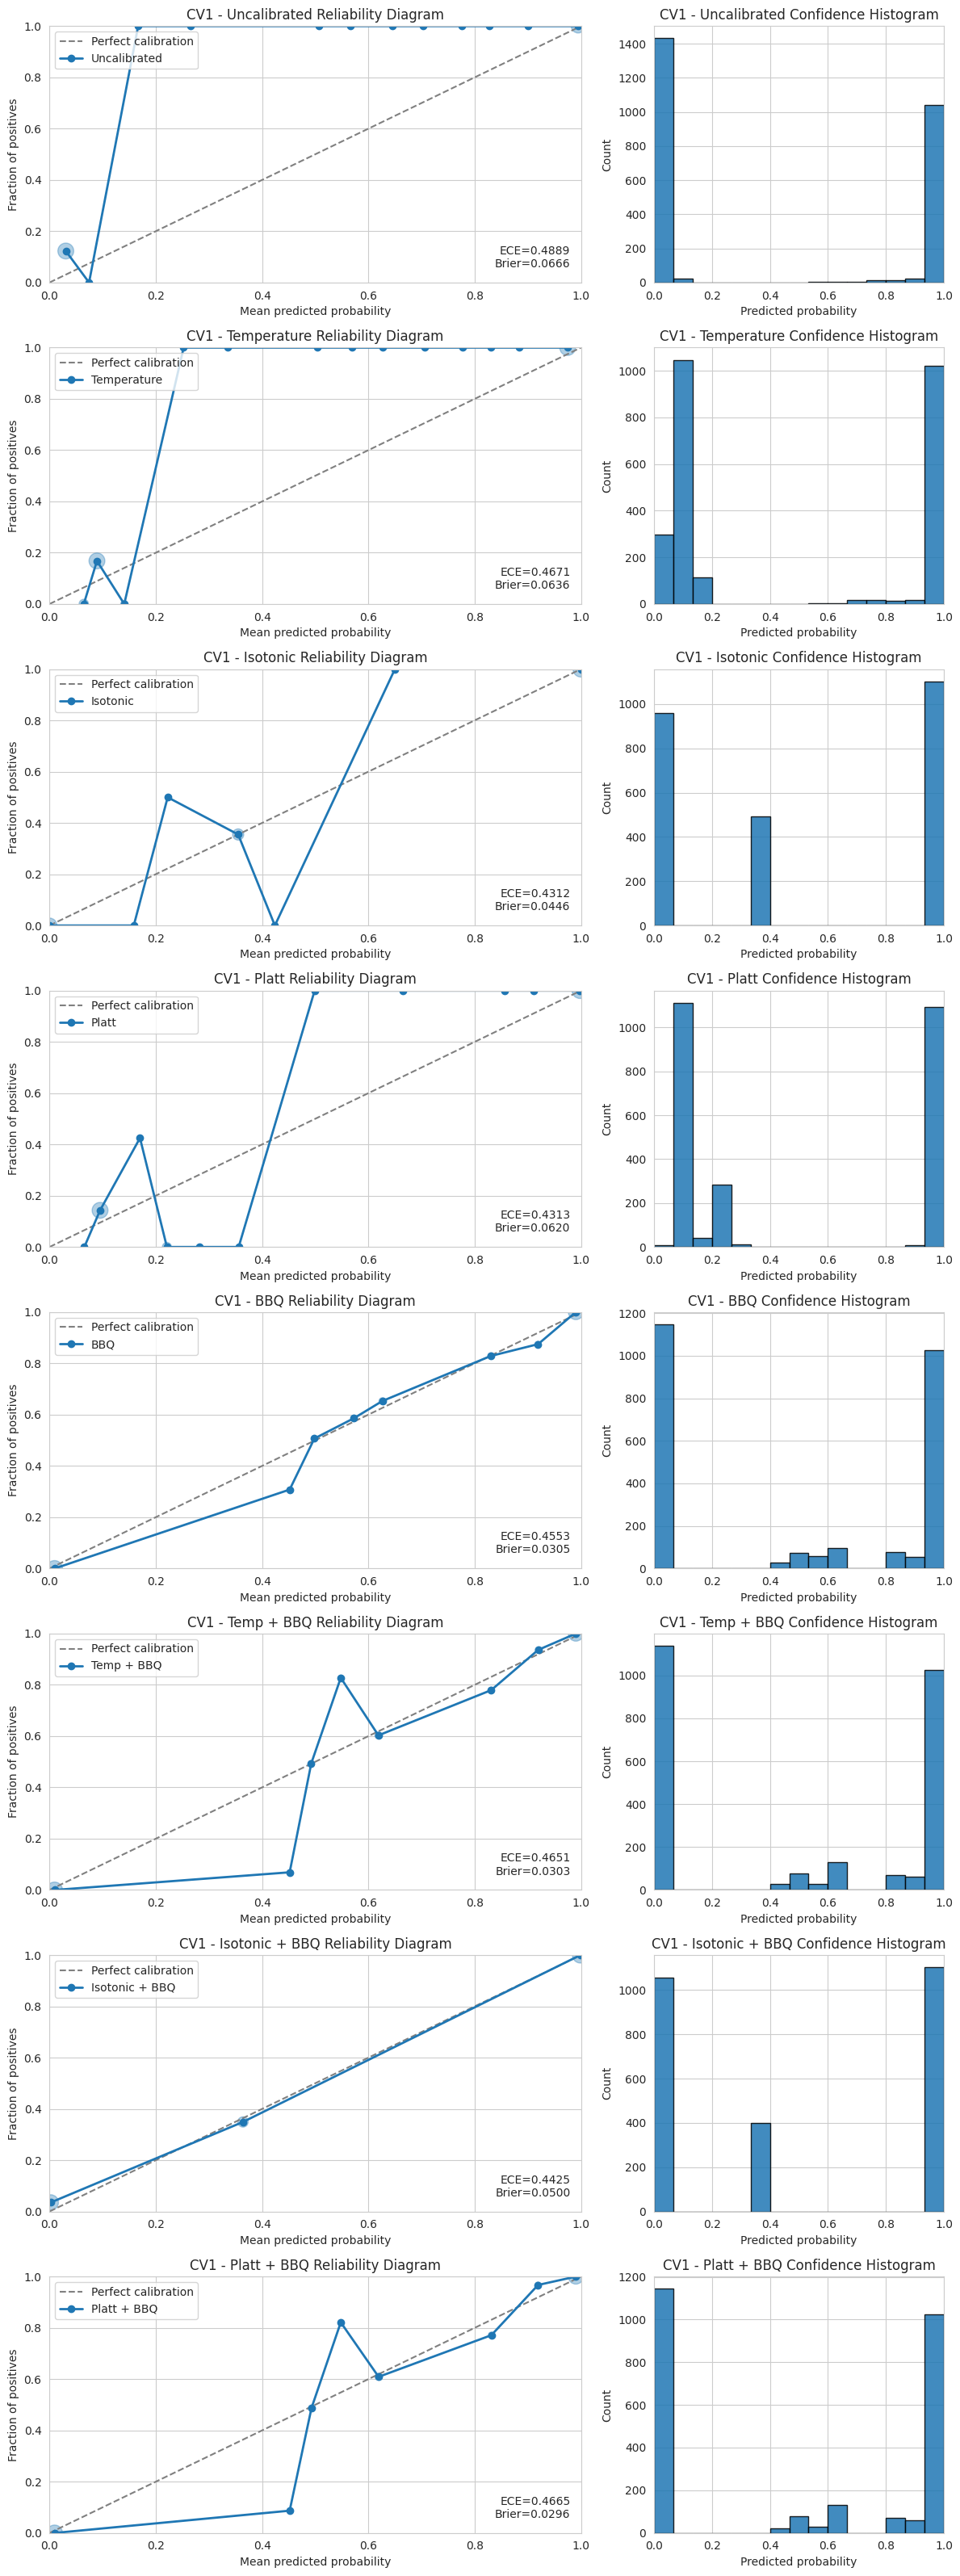

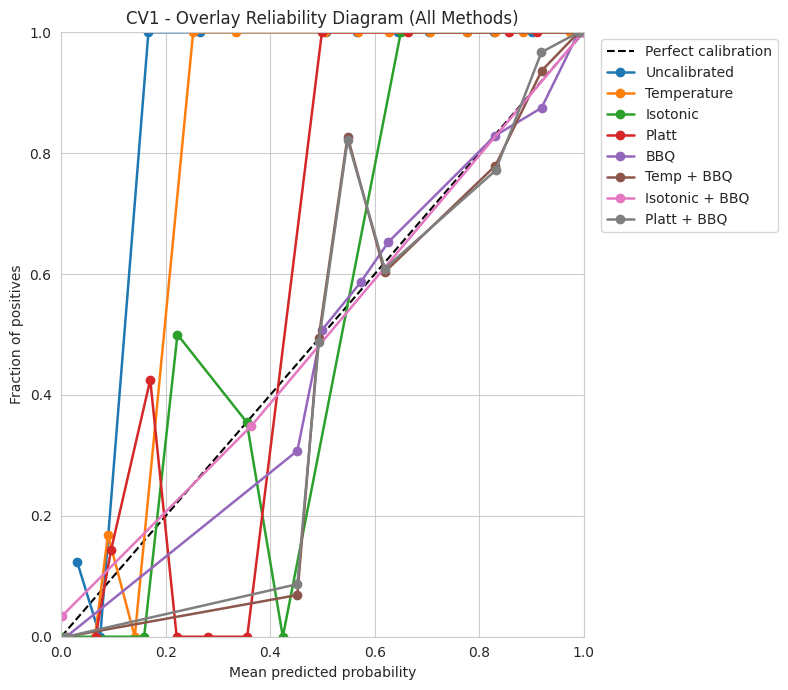

In [4]:
# ============================================
# Reliability Diagrams + Confidence Histograms
# Includes uncalibrated and all calibrated methods
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add near top of cell
current_plot_fold = "CV1"   # change to CV2/CV3/CV4 when needed
sns.set_style("whitegrid")

# ---------- Helpers ----------
def calibration_curve_manual(y_true, y_prob, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    prob_true = np.zeros(n_bins)
    prob_pred = np.zeros(n_bins)
    counts = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            idx = (y_prob >= lo) & (y_prob < hi)
        else:
            idx = (y_prob >= lo) & (y_prob <= hi)

        counts[i] = np.sum(idx)
        if counts[i] > 0:
            prob_true[i] = np.mean(y_true[idx])
            prob_pred[i] = np.mean(y_prob[idx])
        else:
            prob_true[i] = np.nan
            prob_pred[i] = np.nan

    return bin_centers, prob_true, prob_pred, counts

def expected_calibration_error(y_true, y_prob, n_bins=15):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            idx = (y_prob >= lo) & (y_prob < hi)
        else:
            idx = (y_prob >= lo) & (y_prob <= hi)

        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * np.abs(acc_bin - conf_bin)
    return ece / len(y_true)

# ---------- Collect methods ----------
# These variables are expected from your prior calibration cell:
# y_val, calibrated_outputs (dict with keys below)

required_keys = [
    "uncalibrated",
    "temperature",
    "isotonic",
    "platt",
    "bbq",
    "temperature_bbq",
    "isotonic_bbq",
    "platt_bbq",
]
for k in required_keys:
    assert k in calibrated_outputs, f"Missing key in calibrated_outputs: {k}"

method_order = [
    ("uncalibrated",      "Uncalibrated"),
    ("temperature",       "Temperature"),
    ("isotonic",          "Isotonic"),
    ("platt",             "Platt"),
    ("bbq",               "BBQ"),
    ("temperature_bbq",   "Temp + BBQ"),
    ("isotonic_bbq",      "Isotonic + BBQ"),
    ("platt_bbq",         "Platt + BBQ"),
]

# ---------- Compute summary ----------
summary = []
for key, label in method_order:
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)
    ece = expected_calibration_error(y_val, p, n_bins=15)
    brier = np.mean((p - y_val) ** 2)
    summary.append((label, ece, brier))

summary = sorted(summary, key=lambda x: x[1])  # sort by ECE
print("=== Calibration summary (sorted by ECE) ===")
for label, ece, brier in summary:
    print(f"{label:16s} | ECE={ece:.4f} | Brier={brier:.4f}")

# ---------- Plot ----------
# 8 methods x (reliability + histogram) => 8 rows, 2 cols
fig, axes = plt.subplots(
    nrows=len(method_order), ncols=2,
    figsize=(12, 4 * len(method_order)),
    gridspec_kw={"width_ratios": [2.2, 1.2]}
)

if len(method_order) == 1:
    axes = np.array([axes])  # guard for shape consistency

for r, (key, label) in enumerate(method_order):
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)

    # Reliability diagram
    ax_rel = axes[r, 0]
    centers, prob_true, prob_pred, counts = calibration_curve_manual(y_val, p, n_bins=15)
    valid = ~np.isnan(prob_true)

    ax_rel.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Perfect calibration")
    ax_rel.plot(prob_pred[valid], prob_true[valid], marker="o", linewidth=2, label=label)

    # Optional: visualize bin support as bubble size
    if np.any(valid):
        size = 20 + 180 * (counts[valid] / counts.max() if counts.max() > 0 else 1)
        ax_rel.scatter(prob_pred[valid], prob_true[valid], s=size, alpha=0.35)

    ece = expected_calibration_error(y_val, p, n_bins=15)
    brier = np.mean((p - y_val) ** 2)

    ax_rel.set_title(f"{current_plot_fold} - {label} Reliability Diagram")
    ax_rel.set_xlabel("Mean predicted probability")
    ax_rel.set_ylabel("Fraction of positives")
    ax_rel.set_xlim(0, 1)
    ax_rel.set_ylim(0, 1)
    ax_rel.legend(loc="upper left", frameon=True)
    ax_rel.text(
        0.98, 0.05, f"ECE={ece:.4f}\nBrier={brier:.4f}",
        transform=ax_rel.transAxes, ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    # Confidence histogram
    ax_hist = axes[r, 1]
    ax_hist.hist(p, bins=15, range=(0, 1), alpha=0.85, edgecolor="black")
    ax_hist.set_title(f"{current_plot_fold} - {label} Confidence Histogram")
    ax_hist.set_xlabel("Predicted probability")
    ax_hist.set_ylabel("Count")
    ax_hist.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# ---------- Optional: single combined overlay reliability plot ----------
plt.figure(figsize=(8, 7))
plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1.5, label="Perfect calibration")

for key, label in method_order:
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)
    _, prob_true, prob_pred, _ = calibration_curve_manual(y_val, p, n_bins=15)
    valid = ~np.isnan(prob_true)
    plt.plot(prob_pred[valid], prob_true[valid], marker="o", linewidth=1.8, label=label)

plt.title(f"{current_plot_fold} - Overlay Reliability Diagram (All Methods)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [5]:
# =====================================================
# 4-Fold Cross-Validation using CNN-LSTM (Manual CV Control) CV2
# =====================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
import os
from datetime import datetime

# --------------------------------------------
# Base path and folds
# --------------------------------------------
base_partitioned_path = r"/content/drive/My Drive/Vibration June 2026/CNN LSTM"
num_folds = 4

# --------------------------------------------
# Helper: statistical features
# --------------------------------------------
def calculate_statistical_features(vibration_data):
    vibration_data = pd.Series(vibration_data).dropna()
    if vibration_data.empty:
        return np.array([0.0, 0.0, 0.0, 0.0])
    peak_to_peak = np.ptp(vibration_data)
    kurtosis = vibration_data.kurtosis() if len(vibration_data) > 3 else 0.0
    skewness = vibration_data.skew() if len(vibration_data) > 2 else 0.0
    variance = vibration_data.var() if len(vibration_data) > 1 else 0.0
    return np.array([peak_to_peak, kurtosis, skewness, variance])

# --------------------------------------------
# Dataset generator
# --------------------------------------------
def dataset_generator(file_list, global_max_timesteps, global_max_features):
    for f in file_list:
        try:
            df = pd.read_excel(f, skiprows=1, header=None)
            df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
            sequence_label = int(df.iloc[0, 0])
            amplitude_data = df.iloc[:, 1].astype(float)
            other_features_data = df.iloc[:, 2:4].astype(float)
            extra_features = calculate_statistical_features(amplitude_data)
            extra_features_expanded = np.tile(extra_features, (len(amplitude_data), 1))
            sample = np.hstack((amplitude_data.values.reshape(-1, 1),
                                other_features_data.values,
                                extra_features_expanded))
            # Pad/truncate
            if sample.shape[0] < global_max_timesteps:
                row_padding = np.zeros((global_max_timesteps - sample.shape[0], sample.shape[1]))
                sample = np.vstack((sample, row_padding))
            elif sample.shape[0] > global_max_timesteps:
                sample = sample[:global_max_timesteps, :]
            # Pad features if needed
            if sample.shape[1] < global_max_features:
                col_padding = np.zeros((sample.shape[0], global_max_features - sample.shape[1]))
                sample = np.hstack((sample, col_padding))
            elif sample.shape[1] > global_max_features:
                sample = sample[:, :global_max_features]
            yield sample.astype(np.float32), sequence_label
        except Exception as e:
            print(f"Error loading {f}: {e}")
            continue

def make_tf_dataset(file_list, global_max_timesteps, global_max_features, batch_size=64, shuffle=True):
    output_signature = (
        tf.TensorSpec(shape=(global_max_timesteps, global_max_features), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(
        lambda: dataset_generator(file_list, global_max_timesteps, global_max_features),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------------------------------------
# CNN-LSTM model
# --------------------------------------------
def build_model(input_shape,
                conv_filters=32,
                kernel_size=5,
                pool_size=2,
                lstm_units=64,
                dense_units=32,
                dropout_rate=0.3,
                learning_rate=1e-4):
    print("\n=== Building CNN-LSTM model ===")
    model = models.Sequential()
    model.add(Input(shape=input_shape))
    model.add(layers.Normalization())
    model.add(layers.Conv1D(conv_filters, kernel_size, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=pool_size))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.2))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --------------------------------------------
# Calibration Error helper
# --------------------------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * abs(acc_bin - conf_bin)
    return ece / len(y_true)

# --------------------------------------------
# Manual CV control
# --------------------------------------------
current_fold_index = 1  # Change 0–3 for CV1–CV4
print(f"\n=== Running CV{current_fold_index + 1} ===")

cv_splits = {
    0: {"train": ["Fold1", "Fold2", "Fold3"], "val": ["Fold4"]},
    1: {"train": ["Fold1", "Fold2", "Fold4"], "val": ["Fold3"]},
    2: {"train": ["Fold1", "Fold3", "Fold4"], "val": ["Fold2"]},
    3: {"train": ["Fold2", "Fold3", "Fold4"], "val": ["Fold1"]},
}

train_folds = cv_splits[current_fold_index]["train"]
val_folds   = cv_splits[current_fold_index]["val"]

train_files, val_files = [], []
for fold in train_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    train_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

for fold in val_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    val_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

print(f"Training folds: {train_folds}, Validation fold: {val_folds}")
print(f"Train files: {len(train_files)}, Validation files: {len(val_files)}")

# --------------------------------------------
# Determine global max timesteps/features
# --------------------------------------------
print("\n=== Determining global max timesteps/features ===")
temp_raw_data_shapes = []
for f in train_files + val_files:
    try:
        df = pd.read_excel(f, skiprows=1, header=None).apply(pd.to_numeric, errors='coerce').fillna(0)
        amplitude_data_temp = df.iloc[:, 1].astype(float)
        other_features_data_temp = df.iloc[:, 2:4].astype(float)
        extra_features_temp = calculate_statistical_features(amplitude_data_temp)
        combined_feature_count = other_features_data_temp.shape[1] + 1 + len(extra_features_temp)
        temp_raw_data_shapes.append((df.shape[0], combined_feature_count))
    except Exception as e:
        print(f"Warning: {f} shape error: {e}")
        continue

global_max_timesteps = min(max(s[0] for s in temp_raw_data_shapes), 1000)
global_max_features  = max(s[1] for s in temp_raw_data_shapes)
print(f"Global max timesteps: {global_max_timesteps}, Global max features: {global_max_features}")

# --------------------------------------------
# Build streaming datasets
# --------------------------------------------
print("\n=== Preparing streaming datasets ===")
train_ds = make_tf_dataset(train_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=True)
val_ds   = make_tf_dataset(val_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=False)

# --------------------------------------------
# Train model
# --------------------------------------------
model = build_model(input_shape=(global_max_timesteps, global_max_features))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

batch_size = 64  # keep this consistent everywhere

print("\n=== Model training started ===")
steps_per_epoch = max(1, len(train_files) // batch_size)
validation_steps = max(1, len(val_files) // batch_size)

history = model.fit(
    train_ds.repeat(),
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds.repeat(),
    validation_steps=validation_steps,
    callbacks=[early_stop]
)

print("\n=== Model training completed ===")

# --------------------------------------------
# Predictions and Evaluation
# --------------------------------------------
print("\n=== Generating predictions on validation fold ===")
y_prob = model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Collecting true labels from validation dataset ===")
y_val = np.concatenate([y.numpy() for _, y in val_ds], axis=0)

# --------------------------------------------
# Save CV4 outputs to Drive (for reuse)
# --------------------------------------------
import os
import json
import numpy as np
from datetime import datetime

save_dir = "/content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs"
os.makedirs(save_dir, exist_ok=True)

fold_tag = f"CV{current_fold_index + 1}"   # CV4 if current_fold_index=3
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1) Save raw arrays (main file you will reload later)
npz_path_latest = os.path.join(save_dir, f"{fold_tag}_latest_outputs.npz")
npz_path_versioned = os.path.join(save_dir, f"{fold_tag}_{timestamp}_outputs.npz")

np.savez_compressed(
    npz_path_latest,
    y_prob=y_prob.astype(np.float32),
    y_pred=y_pred.astype(np.int32),
    y_val=y_val.astype(np.int32)
)
np.savez_compressed(
    npz_path_versioned,
    y_prob=y_prob.astype(np.float32),
    y_pred=y_pred.astype(np.int32),
    y_val=y_val.astype(np.int32)
)

# 2) Save metadata (optional but useful)
meta = {
    "fold": fold_tag,
    "timestamp": timestamp,
    "num_samples": int(len(y_val)),
    "train_folds": train_folds,
    "val_folds": val_folds,
    "global_max_timesteps": int(global_max_timesteps),
    "global_max_features": int(global_max_features),
    "batch_size": int(batch_size)
}
meta_path_latest = os.path.join(save_dir, f"{fold_tag}_latest_metadata.json")
meta_path_versioned = os.path.join(save_dir, f"{fold_tag}_{timestamp}_metadata.json")

with open(meta_path_latest, "w") as f:
    json.dump(meta, f, indent=2)
with open(meta_path_versioned, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved latest outputs: {npz_path_latest}")
print(f"Saved versioned outputs: {npz_path_versioned}")
print(f"Saved metadata: {meta_path_latest}")

print("\n=== Computing metrics ===")
acc = accuracy_score(y_val, y_pred)

# Healthy = 0, Faulty = 1
prec_H = precision_score(y_val, y_pred, pos_label=0)
prec_F = precision_score(y_val, y_pred, pos_label=1)
rec_H  = recall_score(y_val, y_pred, pos_label=0)
rec_F  = recall_score(y_val, y_pred, pos_label=1)
f1     = f1_score(y_val, y_pred, pos_label=1)  # F1 for faulty class
brier  = brier_score_loss(y_val, y_prob)
ece    = expected_calibration_error(y_val, y_prob)

print(f"\n=== Performance for CV{current_fold_index + 1} ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Healthy=0): {prec_H:.4f}")
print(f"Precision (Faulty=1): {prec_F:.4f}")
print(f"Recall (Healthy=0): {rec_H:.4f}")
print(f"Recall (Faulty=1): {rec_F:.4f}")
print(f"F1 Score (Faulty=1): {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"ECE: {ece:.4f}")

# --------------------------------------------
# Clear session after each fold
# --------------------------------------------
print("\n=== Clearing TensorFlow session ===")
tf.keras.backend.clear_session()

# Keep these variables for calibration in Cell 3
print("\n=== Variables saved for calibration ===")
print(f"y_prob shape: {y_prob.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_pred shape: {y_pred.shape}")


=== Running CV2 ===
Training folds: ['Fold1', 'Fold2', 'Fold4'], Validation fold: ['Fold3']
Train files: 7680, Validation files: 2560

=== Determining global max timesteps/features ===
Global max timesteps: 1000, Global max features: 7

=== Preparing streaming datasets ===

=== Building CNN-LSTM model ===

=== Model training started ===
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1894s 7s/step - accuracy: 0.5781 - loss: 0.6783 - val_accuracy: 0.6953 - val_loss: 0.6152
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1578s 7s/step - accuracy: 0.6335 - loss: 0.6394 - val_accuracy: 0.7500 - val_loss: 0.5517
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1575s 7s/step - accuracy: 0.7053 - loss: 0.5850 - val_accuracy: 0.7855 - val_loss: 0.5104
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1572s 7s/step - accuracy: 0.7630 - loss: 0.5195 - val_accuracy: 0.8180 - val_loss: 0.4644
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1568s 7s/step - accuracy: 0.8132 - loss: 0.4417 - val_accuracy: 0.8395 - val_loss: 0.4393
Epoch 6/20

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Saved latest outputs: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV2_latest_outputs.npz
Saved versioned outputs: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV2_20260627_143759_outputs.npz
Saved metadata: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV2_latest_metadata.json

=== Computing metrics ===

=== Performance for CV2 ===
Accuracy: 0.8719
Precision (Healthy=0): 0.7960
Precision (Faulty=1): 1.0000
Recall (Healthy=0): 1.0000
Recall (Faulty=1): 0.7438
F1 Score (Faulty=1): 0.8530
Brier Score: 0.1118
ECE: 0.4943

=== Clearing TensorFlow session ===

=== Variables saved for calibration ===
y_prob shape: (2560,)
y_val shape: (2560,)
y_pred shape: (2560,)


In [7]:
# ============================================
# CV2 Post-hoc Calibration Suite
# Methods: Temp, Isotonic, Platt, BBQ, Hybrids
# ============================================

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss, log_loss
)
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from scipy.special import logit, expit
from scipy.optimize import minimize_scalar

# -----------------------------
# Paths
# -----------------------------
save_dir = "/content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs"
fold_tag = "CV2"

npz_path = os.path.join(save_dir, f"{fold_tag}_latest_outputs.npz")
assert os.path.exists(npz_path), f"Missing file: {npz_path}"

data = np.load(npz_path)
y_prob_raw = data["y_prob"].astype(np.float64).ravel()
y_val = data["y_val"].astype(np.int32).ravel()

# Safety clipping to avoid inf logits
eps = 1e-6
y_prob_raw = np.clip(y_prob_raw, eps, 1 - eps)

print(f"Loaded {fold_tag} outputs: y_prob={y_prob_raw.shape}, y_val={y_val.shape}")

# -----------------------------
# Metrics helpers
# -----------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1]) if i < n_bins-1 else (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * np.abs(acc_bin - conf_bin)
    return ece / len(y_true)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_prob = np.clip(y_prob, eps, 1-eps)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_healthy_0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_faulty_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_healthy_0": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_faulty_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_faulty_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "brier": brier_score_loss(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=15),
        "nll": log_loss(y_true, y_prob),
    }

# -----------------------------
# Temperature Scaling
# -----------------------------
def fit_temperature(y_true, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps))

    def objective(T):
        T = max(T, 1e-3)
        p = expit(z / T)
        return log_loss(y_true, np.clip(p, eps, 1-eps))

    res = minimize_scalar(objective, bounds=(0.05, 10.0), method='bounded')
    T_opt = float(res.x)
    return T_opt

def apply_temperature(y_prob, T):
    z = logit(np.clip(y_prob, eps, 1-eps))
    return np.clip(expit(z / T), eps, 1-eps)

# -----------------------------
# Platt Scaling
# -----------------------------
def fit_platt(y_true, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps)).reshape(-1, 1)
    lr = LogisticRegression(solver="lbfgs")
    lr.fit(z, y_true)
    return lr

def apply_platt(model, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps)).reshape(-1, 1)
    return np.clip(model.predict_proba(z)[:, 1], eps, 1-eps)

# -----------------------------
# Isotonic Regression
# -----------------------------
def fit_isotonic(y_true, y_prob):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_prob, y_true)
    return iso

def apply_isotonic(model, y_prob):
    return np.clip(model.predict(y_prob), eps, 1-eps)

# -----------------------------
# BBQ (Bayesian Binning into Quantiles)
# Simple robust implementation:
# - Quantile bins
# - Beta-binomial posterior mean per bin with alpha=beta=1
# -----------------------------
class BBQCalibrator:
    def __init__(self, n_bins=20, alpha=1.0, beta=1.0):
        self.n_bins = n_bins
        self.alpha = alpha
        self.beta = beta
        self.bin_edges_ = None
        self.bin_post_mean_ = None

    def fit(self, y_prob, y_true):
        y_prob = np.asarray(y_prob)
        y_true = np.asarray(y_true)

        # Quantile edges (unique + full range guards)
        q = np.linspace(0, 1, self.n_bins + 1)
        edges = np.quantile(y_prob, q)
        edges[0] = 0.0
        edges[-1] = 1.0
        edges = np.unique(edges)
        if len(edges) < 3:
            edges = np.array([0.0, 0.5, 1.0])

        self.bin_edges_ = edges
        self.bin_post_mean_ = np.zeros(len(edges)-1, dtype=float)

        for i in range(len(edges)-1):
            lo, hi = edges[i], edges[i+1]
            if i < len(edges)-2:
                idx = (y_prob >= lo) & (y_prob < hi)
            else:
                idx = (y_prob >= lo) & (y_prob <= hi)

            n = np.sum(idx)
            k = np.sum(y_true[idx]) if n > 0 else 0.0

            # Beta posterior mean
            p_hat = (k + self.alpha) / (n + self.alpha + self.beta)
            self.bin_post_mean_[i] = p_hat

        return self

    def predict(self, y_prob):
        y_prob = np.asarray(y_prob)
        out = np.zeros_like(y_prob, dtype=float)
        edges = self.bin_edges_

        bin_ids = np.digitize(y_prob, edges[1:-1], right=False)
        out = self.bin_post_mean_[bin_ids]
        return np.clip(out, eps, 1-eps)

# -----------------------------
# OOF fitting helper to reduce overfit on same fold
# -----------------------------
def oof_calibrated_probs(y_true, y_prob, method="temperature", n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = np.zeros_like(y_prob, dtype=float)

    for tr_idx, te_idx in skf.split(y_prob.reshape(-1,1), y_true):
        yt_tr, yp_tr = y_true[tr_idx], y_prob[tr_idx]
        yp_te = y_prob[te_idx]

        if method == "temperature":
            T = fit_temperature(yt_tr, yp_tr)
            oof[te_idx] = apply_temperature(yp_te, T)

        elif method == "platt":
            m = fit_platt(yt_tr, yp_tr)
            oof[te_idx] = apply_platt(m, yp_te)

        elif method == "isotonic":
            m = fit_isotonic(yt_tr, yp_tr)
            oof[te_idx] = apply_isotonic(m, yp_te)

        elif method == "bbq":
            m = BBQCalibrator(n_bins=20, alpha=1.0, beta=1.0).fit(yp_tr, yt_tr)
            oof[te_idx] = m.predict(yp_te)

        else:
            raise ValueError(f"Unknown method: {method}")

    return np.clip(oof, eps, 1-eps)

# -----------------------------
# Run calibrations
# -----------------------------
results = {}
calibrated_outputs = {}

# Baseline
results["uncalibrated"] = compute_metrics(y_val, y_prob_raw)
calibrated_outputs["uncalibrated"] = y_prob_raw

# Single methods (OOF-style)
p_temp = oof_calibrated_probs(y_val, y_prob_raw, method="temperature")
p_iso  = oof_calibrated_probs(y_val, y_prob_raw, method="isotonic")
p_platt= oof_calibrated_probs(y_val, y_prob_raw, method="platt")
p_bbq  = oof_calibrated_probs(y_val, y_prob_raw, method="bbq")

calibrated_outputs["temperature"] = p_temp
calibrated_outputs["isotonic"] = p_iso
calibrated_outputs["platt"] = p_platt
calibrated_outputs["bbq"] = p_bbq

results["temperature"] = compute_metrics(y_val, p_temp)
results["isotonic"] = compute_metrics(y_val, p_iso)
results["platt"] = compute_metrics(y_val, p_platt)
results["bbq"] = compute_metrics(y_val, p_bbq)

# Hybrids: first method then BBQ
# (again OOF chain to reduce leakage)
p_temp_bbq = oof_calibrated_probs(y_val, p_temp, method="bbq")
p_iso_bbq  = oof_calibrated_probs(y_val, p_iso, method="bbq")
p_platt_bbq= oof_calibrated_probs(y_val, p_platt, method="bbq")

calibrated_outputs["temperature_bbq"] = p_temp_bbq
calibrated_outputs["isotonic_bbq"] = p_iso_bbq
calibrated_outputs["platt_bbq"] = p_platt_bbq

results["temperature_bbq"] = compute_metrics(y_val, p_temp_bbq)
results["isotonic_bbq"] = compute_metrics(y_val, p_iso_bbq)
results["platt_bbq"] = compute_metrics(y_val, p_platt_bbq)

# -----------------------------
# Display comparison table
# -----------------------------
df_res = pd.DataFrame(results).T
df_res = df_res[[
    "accuracy",
    "precision_healthy_0",
    "precision_faulty_1",
    "recall_healthy_0",
    "recall_faulty_1",
    "f1_faulty_1",
    "brier",
    "ece",
    "nll",
]].sort_values("ece")

print("\n=== Calibration Comparison (sorted by ECE lower is better) ===")
display(df_res.style.format("{:.4f}"))

# -----------------------------
# Save outputs
# -----------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
calib_npz_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_outputs.npz")
calib_json_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_metrics.json")
calib_csv_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_metrics.csv")

np.savez_compressed(
    calib_npz_path,
    y_val=y_val.astype(np.int32),
    y_prob_uncalibrated=y_prob_raw.astype(np.float32),
    y_prob_temperature=p_temp.astype(np.float32),
    y_prob_isotonic=p_iso.astype(np.float32),
    y_prob_platt=p_platt.astype(np.float32),
    y_prob_bbq=p_bbq.astype(np.float32),
    y_prob_temperature_bbq=p_temp_bbq.astype(np.float32),
    y_prob_isotonic_bbq=p_iso_bbq.astype(np.float32),
    y_prob_platt_bbq=p_platt_bbq.astype(np.float32),
)

with open(calib_json_path, "w") as f:
    json.dump({k: {kk: float(vv) for kk, vv in v.items()} for k, v in results.items()}, f, indent=2)

df_res.to_csv(calib_csv_path, index=True)

print(f"\nSaved calibration probs: {calib_npz_path}")
print(f"Saved calibration metrics JSON: {calib_json_path}")
print(f"Saved calibration metrics CSV: {calib_csv_path}")

Loaded CV2 outputs: y_prob=(2560,), y_val=(2560,)

=== Calibration Comparison (sorted by ECE lower is better) ===


,accuracy,precision_healthy_0,precision_faulty_1,recall_healthy_0,recall_faulty_1,f1_faulty_1,brier,ece,nll
platt,0.8883,0.8305,0.9706,0.9758,0.8008,0.8776,0.0901,0.3948,0.2789
isotonic,0.8957,0.8313,0.9913,0.9930,0.7984,0.8845,0.0597,0.3985,0.1768
isotonic_bbq,0.8906,0.8521,0.9386,0.9453,0.8359,0.8843,0.0732,0.4185,0.2802
bbq,0.9410,0.9455,0.9366,0.9359,0.9461,0.9413,0.0367,0.4415,0.1235
temperature_bbq,0.9453,0.9524,0.9385,0.9375,0.9531,0.9457,0.0363,0.4434,0.1244
platt_bbq,0.9445,0.9494,0.9397,0.9391,0.9500,0.9448,0.0364,0.4444,0.1237
temperature,0.8719,0.7960,1.0000,1.0000,0.7438,0.8530,0.1016,0.4669,0.3382
uncalibrated,0.8719,0.7960,1.0000,1.0000,0.7438,0.8530,0.1118,0.4936,0.4072



Saved calibration probs: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV2_20260627_162923_calibration_outputs.npz
Saved calibration metrics JSON: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV2_20260627_162923_calibration_metrics.json
Saved calibration metrics CSV: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV2_20260627_162923_calibration_metrics.csv


=== Calibration summary (sorted by ECE) ===
Platt            | ECE=0.3948 | Brier=0.0901
Isotonic         | ECE=0.3985 | Brier=0.0597
Isotonic + BBQ   | ECE=0.4185 | Brier=0.0732
BBQ              | ECE=0.4415 | Brier=0.0367
Temp + BBQ       | ECE=0.4434 | Brier=0.0363
Platt + BBQ      | ECE=0.4444 | Brier=0.0364
Temperature      | ECE=0.4669 | Brier=0.1016
Uncalibrated     | ECE=0.4936 | Brier=0.1118


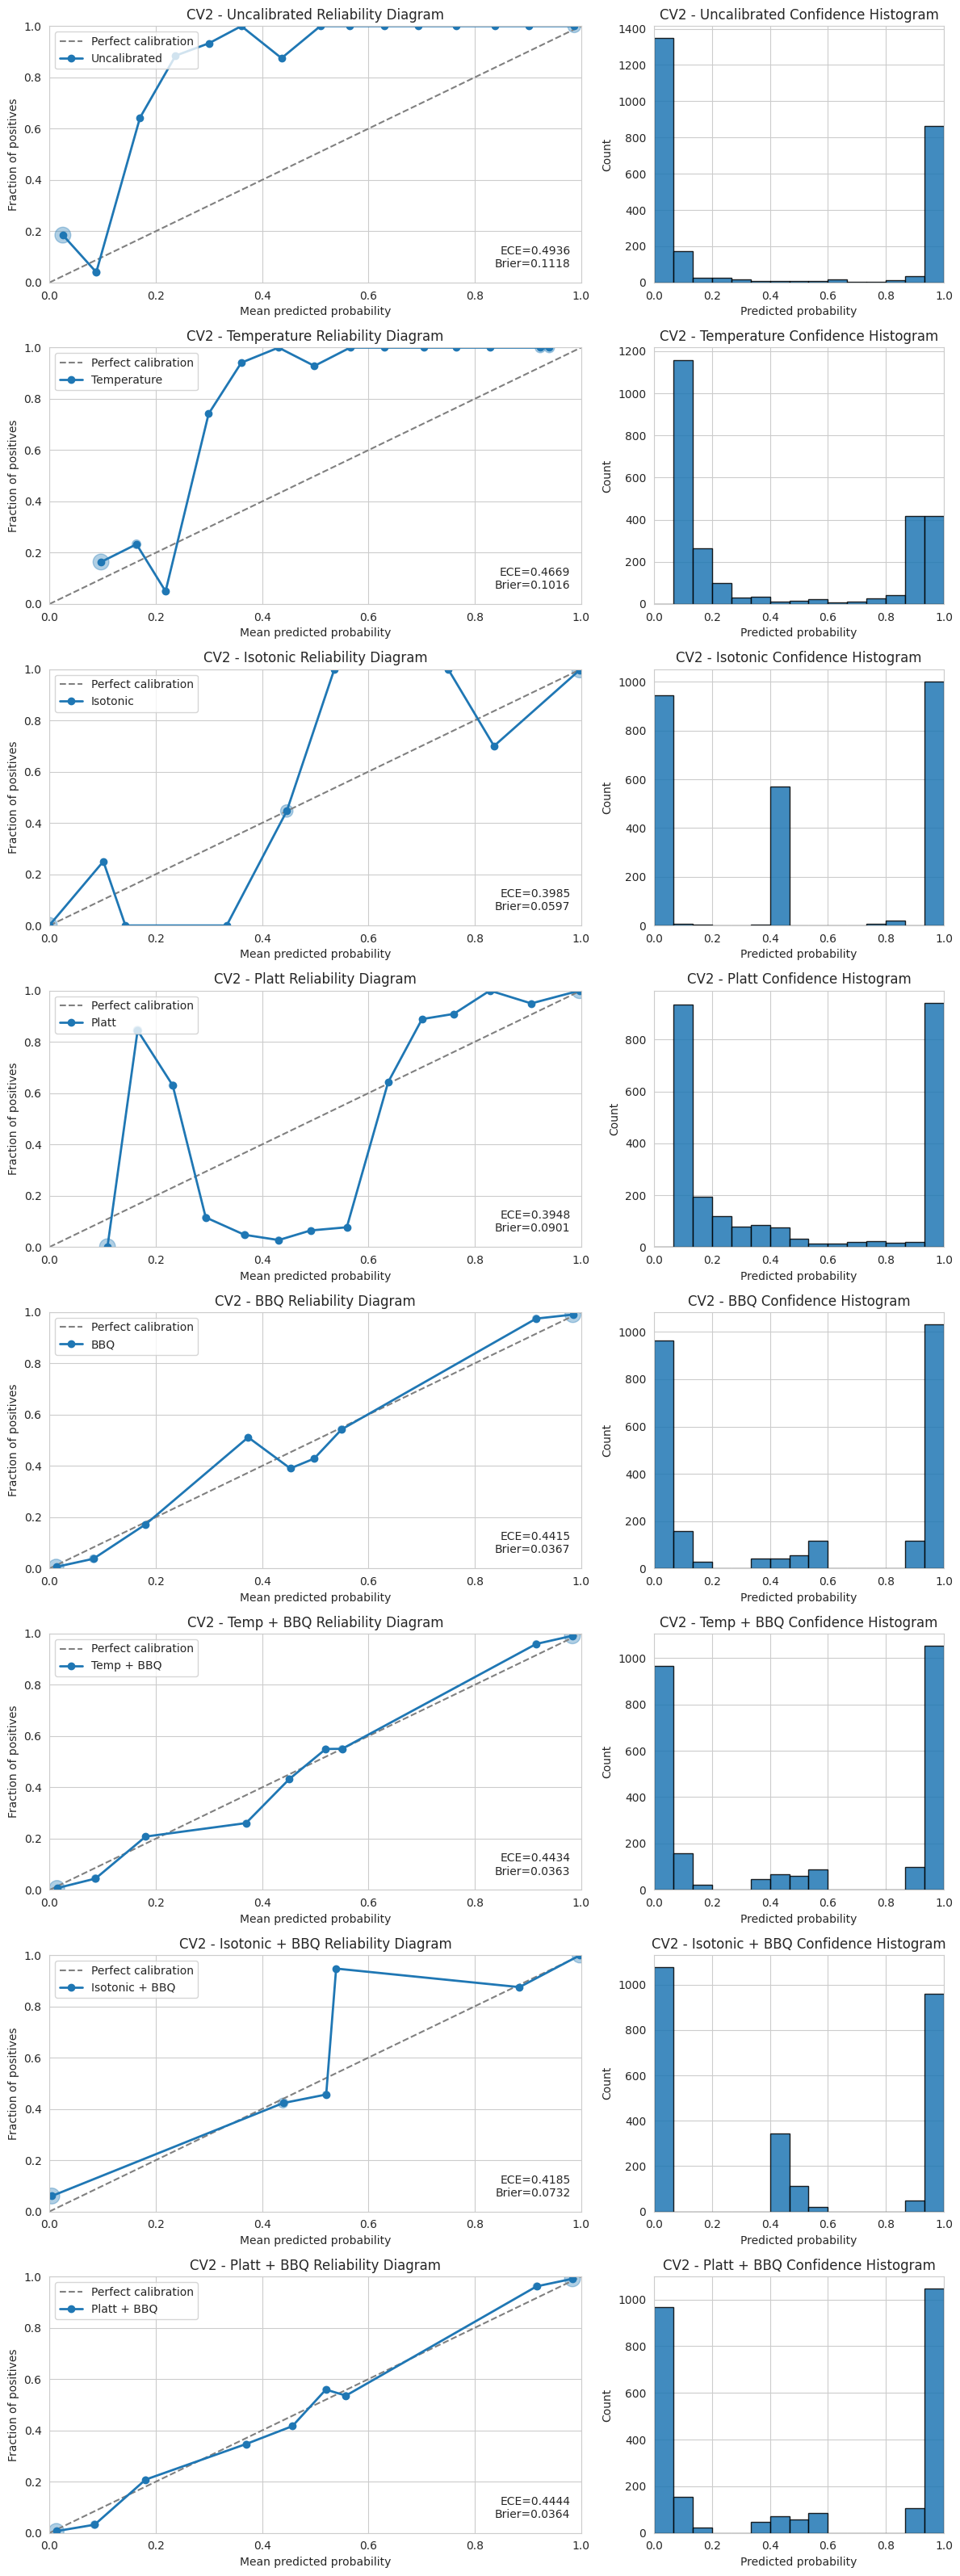

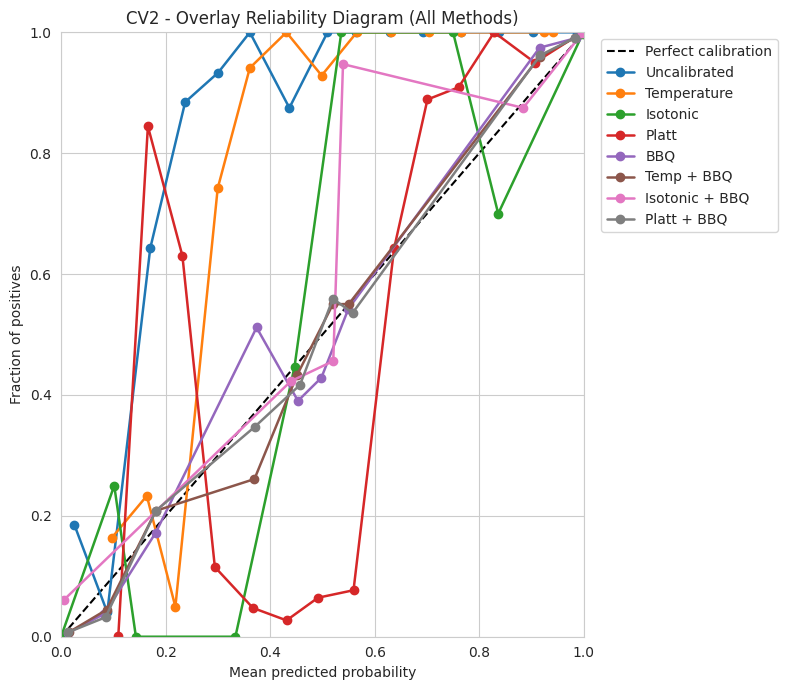

In [8]:
# ============================================
# Reliability Diagrams + Confidence Histograms
# Includes uncalibrated and all calibrated methods
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add near top of cell
current_plot_fold = "CV2"   # change to CV2/CV3/CV4 when needed
sns.set_style("whitegrid")

# ---------- Helpers ----------
def calibration_curve_manual(y_true, y_prob, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    prob_true = np.zeros(n_bins)
    prob_pred = np.zeros(n_bins)
    counts = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            idx = (y_prob >= lo) & (y_prob < hi)
        else:
            idx = (y_prob >= lo) & (y_prob <= hi)

        counts[i] = np.sum(idx)
        if counts[i] > 0:
            prob_true[i] = np.mean(y_true[idx])
            prob_pred[i] = np.mean(y_prob[idx])
        else:
            prob_true[i] = np.nan
            prob_pred[i] = np.nan

    return bin_centers, prob_true, prob_pred, counts

def expected_calibration_error(y_true, y_prob, n_bins=15):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            idx = (y_prob >= lo) & (y_prob < hi)
        else:
            idx = (y_prob >= lo) & (y_prob <= hi)

        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * np.abs(acc_bin - conf_bin)
    return ece / len(y_true)

# ---------- Collect methods ----------
# These variables are expected from your prior calibration cell:
# y_val, calibrated_outputs (dict with keys below)

required_keys = [
    "uncalibrated",
    "temperature",
    "isotonic",
    "platt",
    "bbq",
    "temperature_bbq",
    "isotonic_bbq",
    "platt_bbq",
]
for k in required_keys:
    assert k in calibrated_outputs, f"Missing key in calibrated_outputs: {k}"

method_order = [
    ("uncalibrated",      "Uncalibrated"),
    ("temperature",       "Temperature"),
    ("isotonic",          "Isotonic"),
    ("platt",             "Platt"),
    ("bbq",               "BBQ"),
    ("temperature_bbq",   "Temp + BBQ"),
    ("isotonic_bbq",      "Isotonic + BBQ"),
    ("platt_bbq",         "Platt + BBQ"),
]

# ---------- Compute summary ----------
summary = []
for key, label in method_order:
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)
    ece = expected_calibration_error(y_val, p, n_bins=15)
    brier = np.mean((p - y_val) ** 2)
    summary.append((label, ece, brier))

summary = sorted(summary, key=lambda x: x[1])  # sort by ECE
print("=== Calibration summary (sorted by ECE) ===")
for label, ece, brier in summary:
    print(f"{label:16s} | ECE={ece:.4f} | Brier={brier:.4f}")

# ---------- Plot ----------
# 8 methods x (reliability + histogram) => 8 rows, 2 cols
fig, axes = plt.subplots(
    nrows=len(method_order), ncols=2,
    figsize=(12, 4 * len(method_order)),
    gridspec_kw={"width_ratios": [2.2, 1.2]}
)

if len(method_order) == 1:
    axes = np.array([axes])  # guard for shape consistency

for r, (key, label) in enumerate(method_order):
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)

    # Reliability diagram
    ax_rel = axes[r, 0]
    centers, prob_true, prob_pred, counts = calibration_curve_manual(y_val, p, n_bins=15)
    valid = ~np.isnan(prob_true)

    ax_rel.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Perfect calibration")
    ax_rel.plot(prob_pred[valid], prob_true[valid], marker="o", linewidth=2, label=label)

    # Optional: visualize bin support as bubble size
    if np.any(valid):
        size = 20 + 180 * (counts[valid] / counts.max() if counts.max() > 0 else 1)
        ax_rel.scatter(prob_pred[valid], prob_true[valid], s=size, alpha=0.35)

    ece = expected_calibration_error(y_val, p, n_bins=15)
    brier = np.mean((p - y_val) ** 2)

    ax_rel.set_title(f"{current_plot_fold} - {label} Reliability Diagram")
    ax_rel.set_xlabel("Mean predicted probability")
    ax_rel.set_ylabel("Fraction of positives")
    ax_rel.set_xlim(0, 1)
    ax_rel.set_ylim(0, 1)
    ax_rel.legend(loc="upper left", frameon=True)
    ax_rel.text(
        0.98, 0.05, f"ECE={ece:.4f}\nBrier={brier:.4f}",
        transform=ax_rel.transAxes, ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    # Confidence histogram
    ax_hist = axes[r, 1]
    ax_hist.hist(p, bins=15, range=(0, 1), alpha=0.85, edgecolor="black")
    ax_hist.set_title(f"{current_plot_fold} - {label} Confidence Histogram")
    ax_hist.set_xlabel("Predicted probability")
    ax_hist.set_ylabel("Count")
    ax_hist.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# ---------- Optional: single combined overlay reliability plot ----------
plt.figure(figsize=(8, 7))
plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1.5, label="Perfect calibration")

for key, label in method_order:
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)
    _, prob_true, prob_pred, _ = calibration_curve_manual(y_val, p, n_bins=15)
    valid = ~np.isnan(prob_true)
    plt.plot(prob_pred[valid], prob_true[valid], marker="o", linewidth=1.8, label=label)

plt.title(f"{current_plot_fold} - Overlay Reliability Diagram (All Methods)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [9]:
# =====================================================
# 4-Fold Cross-Validation using CNN-LSTM (Manual CV Control) CV3
# =====================================================

import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, brier_score_loss
import os
from datetime import datetime

# --------------------------------------------
# Base path and folds
# --------------------------------------------
base_partitioned_path = r"/content/drive/My Drive/Vibration June 2026/CNN LSTM"
num_folds = 4

# --------------------------------------------
# Helper: statistical features
# --------------------------------------------
def calculate_statistical_features(vibration_data):
    vibration_data = pd.Series(vibration_data).dropna()
    if vibration_data.empty:
        return np.array([0.0, 0.0, 0.0, 0.0])
    peak_to_peak = np.ptp(vibration_data)
    kurtosis = vibration_data.kurtosis() if len(vibration_data) > 3 else 0.0
    skewness = vibration_data.skew() if len(vibration_data) > 2 else 0.0
    variance = vibration_data.var() if len(vibration_data) > 1 else 0.0
    return np.array([peak_to_peak, kurtosis, skewness, variance])

# --------------------------------------------
# Dataset generator
# --------------------------------------------
def dataset_generator(file_list, global_max_timesteps, global_max_features):
    for f in file_list:
        try:
            df = pd.read_excel(f, skiprows=1, header=None)
            df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
            sequence_label = int(df.iloc[0, 0])
            amplitude_data = df.iloc[:, 1].astype(float)
            other_features_data = df.iloc[:, 2:4].astype(float)
            extra_features = calculate_statistical_features(amplitude_data)
            extra_features_expanded = np.tile(extra_features, (len(amplitude_data), 1))
            sample = np.hstack((amplitude_data.values.reshape(-1, 1),
                                other_features_data.values,
                                extra_features_expanded))
            # Pad/truncate
            if sample.shape[0] < global_max_timesteps:
                row_padding = np.zeros((global_max_timesteps - sample.shape[0], sample.shape[1]))
                sample = np.vstack((sample, row_padding))
            elif sample.shape[0] > global_max_timesteps:
                sample = sample[:global_max_timesteps, :]
            # Pad features if needed
            if sample.shape[1] < global_max_features:
                col_padding = np.zeros((sample.shape[0], global_max_features - sample.shape[1]))
                sample = np.hstack((sample, col_padding))
            elif sample.shape[1] > global_max_features:
                sample = sample[:, :global_max_features]
            yield sample.astype(np.float32), sequence_label
        except Exception as e:
            print(f"Error loading {f}: {e}")
            continue

def make_tf_dataset(file_list, global_max_timesteps, global_max_features, batch_size=64, shuffle=True):
    output_signature = (
        tf.TensorSpec(shape=(global_max_timesteps, global_max_features), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int32)
    )
    ds = tf.data.Dataset.from_generator(
        lambda: dataset_generator(file_list, global_max_timesteps, global_max_features),
        output_signature=output_signature
    )
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list))
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# --------------------------------------------
# CNN-LSTM model
# --------------------------------------------
def build_model(input_shape,
                conv_filters=32,
                kernel_size=5,
                pool_size=2,
                lstm_units=64,
                dense_units=32,
                dropout_rate=0.3,
                learning_rate=1e-4):
    print("\n=== Building CNN-LSTM model ===")
    model = models.Sequential()
    model.add(Input(shape=input_shape))
    model.add(layers.Normalization())
    model.add(layers.Conv1D(conv_filters, kernel_size, activation='relu'))
    model.add(layers.MaxPooling1D(pool_size=pool_size))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.LSTM(lstm_units, dropout=dropout_rate, recurrent_dropout=0.2))
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# --------------------------------------------
# Calibration Error helper
# --------------------------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * abs(acc_bin - conf_bin)
    return ece / len(y_true)

# --------------------------------------------
# Manual CV control
# --------------------------------------------
current_fold_index = 2  # Change 0–3 for CV1–CV4
print(f"\n=== Running CV{current_fold_index + 1} ===")

cv_splits = {
    0: {"train": ["Fold1", "Fold2", "Fold3"], "val": ["Fold4"]},
    1: {"train": ["Fold1", "Fold2", "Fold4"], "val": ["Fold3"]},
    2: {"train": ["Fold1", "Fold3", "Fold4"], "val": ["Fold2"]},
    3: {"train": ["Fold2", "Fold3", "Fold4"], "val": ["Fold1"]},
}

train_folds = cv_splits[current_fold_index]["train"]
val_folds   = cv_splits[current_fold_index]["val"]

train_files, val_files = [], []
for fold in train_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    train_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

for fold in val_folds:
    fold_path = os.path.join(base_partitioned_path, fold)
    val_files.extend([os.path.join(fold_path, f) for f in os.listdir(fold_path) if f.endswith(('.xls', '.xlsx'))])

print(f"Training folds: {train_folds}, Validation fold: {val_folds}")
print(f"Train files: {len(train_files)}, Validation files: {len(val_files)}")

# --------------------------------------------
# Determine global max timesteps/features
# --------------------------------------------
print("\n=== Determining global max timesteps/features ===")
temp_raw_data_shapes = []
for f in train_files + val_files:
    try:
        df = pd.read_excel(f, skiprows=1, header=None).apply(pd.to_numeric, errors='coerce').fillna(0)
        amplitude_data_temp = df.iloc[:, 1].astype(float)
        other_features_data_temp = df.iloc[:, 2:4].astype(float)
        extra_features_temp = calculate_statistical_features(amplitude_data_temp)
        combined_feature_count = other_features_data_temp.shape[1] + 1 + len(extra_features_temp)
        temp_raw_data_shapes.append((df.shape[0], combined_feature_count))
    except Exception as e:
        print(f"Warning: {f} shape error: {e}")
        continue

global_max_timesteps = min(max(s[0] for s in temp_raw_data_shapes), 1000)
global_max_features  = max(s[1] for s in temp_raw_data_shapes)
print(f"Global max timesteps: {global_max_timesteps}, Global max features: {global_max_features}")

# --------------------------------------------
# Build streaming datasets
# --------------------------------------------
print("\n=== Preparing streaming datasets ===")
train_ds = make_tf_dataset(train_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=True)
val_ds   = make_tf_dataset(val_files, global_max_timesteps, global_max_features, batch_size=64, shuffle=False)

# --------------------------------------------
# Train model
# --------------------------------------------
model = build_model(input_shape=(global_max_timesteps, global_max_features))
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

batch_size = 64  # keep this consistent everywhere

print("\n=== Model training started ===")
steps_per_epoch = max(1, len(train_files) // batch_size)
validation_steps = max(1, len(val_files) // batch_size)

history = model.fit(
    train_ds.repeat(),
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds.repeat(),
    validation_steps=validation_steps,
    callbacks=[early_stop]
)

print("\n=== Model training completed ===")

# --------------------------------------------
# Predictions and Evaluation
# --------------------------------------------
print("\n=== Generating predictions on validation fold ===")
y_prob = model.predict(val_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Collecting true labels from validation dataset ===")
y_val = np.concatenate([y.numpy() for _, y in val_ds], axis=0)

# --------------------------------------------
# Save CV4 outputs to Drive (for reuse)
# --------------------------------------------
import os
import json
import numpy as np
from datetime import datetime

save_dir = "/content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs"
os.makedirs(save_dir, exist_ok=True)

fold_tag = f"CV{current_fold_index + 1}"   # CV4 if current_fold_index=3
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 1) Save raw arrays (main file you will reload later)
npz_path_latest = os.path.join(save_dir, f"{fold_tag}_latest_outputs.npz")
npz_path_versioned = os.path.join(save_dir, f"{fold_tag}_{timestamp}_outputs.npz")

np.savez_compressed(
    npz_path_latest,
    y_prob=y_prob.astype(np.float32),
    y_pred=y_pred.astype(np.int32),
    y_val=y_val.astype(np.int32)
)
np.savez_compressed(
    npz_path_versioned,
    y_prob=y_prob.astype(np.float32),
    y_pred=y_pred.astype(np.int32),
    y_val=y_val.astype(np.int32)
)

# 2) Save metadata (optional but useful)
meta = {
    "fold": fold_tag,
    "timestamp": timestamp,
    "num_samples": int(len(y_val)),
    "train_folds": train_folds,
    "val_folds": val_folds,
    "global_max_timesteps": int(global_max_timesteps),
    "global_max_features": int(global_max_features),
    "batch_size": int(batch_size)
}
meta_path_latest = os.path.join(save_dir, f"{fold_tag}_latest_metadata.json")
meta_path_versioned = os.path.join(save_dir, f"{fold_tag}_{timestamp}_metadata.json")

with open(meta_path_latest, "w") as f:
    json.dump(meta, f, indent=2)
with open(meta_path_versioned, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Saved latest outputs: {npz_path_latest}")
print(f"Saved versioned outputs: {npz_path_versioned}")
print(f"Saved metadata: {meta_path_latest}")

print("\n=== Computing metrics ===")
acc = accuracy_score(y_val, y_pred)

# Healthy = 0, Faulty = 1
prec_H = precision_score(y_val, y_pred, pos_label=0)
prec_F = precision_score(y_val, y_pred, pos_label=1)
rec_H  = recall_score(y_val, y_pred, pos_label=0)
rec_F  = recall_score(y_val, y_pred, pos_label=1)
f1     = f1_score(y_val, y_pred, pos_label=1)  # F1 for faulty class
brier  = brier_score_loss(y_val, y_prob)
ece    = expected_calibration_error(y_val, y_prob)

print(f"\n=== Performance for CV{current_fold_index + 1} ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision (Healthy=0): {prec_H:.4f}")
print(f"Precision (Faulty=1): {prec_F:.4f}")
print(f"Recall (Healthy=0): {rec_H:.4f}")
print(f"Recall (Faulty=1): {rec_F:.4f}")
print(f"F1 Score (Faulty=1): {f1:.4f}")
print(f"Brier Score: {brier:.4f}")
print(f"ECE: {ece:.4f}")

# --------------------------------------------
# Clear session after each fold
# --------------------------------------------
print("\n=== Clearing TensorFlow session ===")
tf.keras.backend.clear_session()

# Keep these variables for calibration in Cell 3
print("\n=== Variables saved for calibration ===")
print(f"y_prob shape: {y_prob.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_pred shape: {y_pred.shape}")


=== Running CV3 ===
Training folds: ['Fold1', 'Fold3', 'Fold4'], Validation fold: ['Fold2']
Train files: 7680, Validation files: 2560

=== Determining global max timesteps/features ===
Global max timesteps: 1000, Global max features: 7

=== Preparing streaming datasets ===

=== Building CNN-LSTM model ===

=== Model training started ===
Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1943s 7s/step - accuracy: 0.5349 - loss: 0.7008 - val_accuracy: 0.6910 - val_loss: 0.6639
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1621s 7s/step - accuracy: 0.6053 - loss: 0.6631 - val_accuracy: 0.8398 - val_loss: 0.5561
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1616s 7s/step - accuracy: 0.6913 - loss: 0.6165 - val_accuracy: 0.7426 - val_loss: 0.5223
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1610s 7s/step - accuracy: 0.7503 - loss: 0.5563 - val_accuracy: 0.7391 - val_loss: 0.5041
Epoch 5/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 1611s 7s/step - accuracy: 0.8009 - loss: 0.4812 - val_accuracy: 0.7863 - val_loss: 0.4688
Epoch 6/20

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


Saved latest outputs: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV3_latest_outputs.npz
Saved versioned outputs: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV3_20260628_014223_outputs.npz
Saved metadata: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV3_latest_metadata.json

=== Computing metrics ===

=== Performance for CV3 ===
Accuracy: 0.8816
Precision (Healthy=0): 0.8086
Precision (Faulty=1): 1.0000
Recall (Healthy=0): 1.0000
Recall (Faulty=1): 0.7633
F1 Score (Faulty=1): 0.8658
Brier Score: 0.1047
ECE: 0.4965

=== Clearing TensorFlow session ===

=== Variables saved for calibration ===
y_prob shape: (2560,)
y_val shape: (2560,)
y_pred shape: (2560,)


In [11]:
# ============================================
# CV3 Post-hoc Calibration Suite
# Methods: Temp, Isotonic, Platt, BBQ, Hybrids
# ============================================

import os
import json
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss, log_loss
)
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from scipy.special import logit, expit
from scipy.optimize import minimize_scalar

# -----------------------------
# Paths
# -----------------------------
save_dir = "/content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs"
fold_tag = "CV3"

npz_path = os.path.join(save_dir, f"{fold_tag}_latest_outputs.npz")
assert os.path.exists(npz_path), f"Missing file: {npz_path}"

data = np.load(npz_path)
y_prob_raw = data["y_prob"].astype(np.float64).ravel()
y_val = data["y_val"].astype(np.int32).ravel()

# Safety clipping to avoid inf logits
eps = 1e-6
y_prob_raw = np.clip(y_prob_raw, eps, 1 - eps)

print(f"Loaded {fold_tag} outputs: y_prob={y_prob_raw.shape}, y_val={y_val.shape}")

# -----------------------------
# Metrics helpers
# -----------------------------
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        idx = (y_prob >= bins[i]) & (y_prob < bins[i+1]) if i < n_bins-1 else (y_prob >= bins[i]) & (y_prob <= bins[i+1])
        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * np.abs(acc_bin - conf_bin)
    return ece / len(y_true)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_prob = np.clip(y_prob, eps, 1-eps)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_healthy_0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_faulty_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_healthy_0": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_faulty_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_faulty_1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "brier": brier_score_loss(y_true, y_prob),
        "ece": expected_calibration_error(y_true, y_prob, n_bins=15),
        "nll": log_loss(y_true, y_prob),
    }

# -----------------------------
# Temperature Scaling
# -----------------------------
def fit_temperature(y_true, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps))

    def objective(T):
        T = max(T, 1e-3)
        p = expit(z / T)
        return log_loss(y_true, np.clip(p, eps, 1-eps))

    res = minimize_scalar(objective, bounds=(0.05, 10.0), method='bounded')
    T_opt = float(res.x)
    return T_opt

def apply_temperature(y_prob, T):
    z = logit(np.clip(y_prob, eps, 1-eps))
    return np.clip(expit(z / T), eps, 1-eps)

# -----------------------------
# Platt Scaling
# -----------------------------
def fit_platt(y_true, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps)).reshape(-1, 1)
    lr = LogisticRegression(solver="lbfgs")
    lr.fit(z, y_true)
    return lr

def apply_platt(model, y_prob):
    z = logit(np.clip(y_prob, eps, 1-eps)).reshape(-1, 1)
    return np.clip(model.predict_proba(z)[:, 1], eps, 1-eps)

# -----------------------------
# Isotonic Regression
# -----------------------------
def fit_isotonic(y_true, y_prob):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_prob, y_true)
    return iso

def apply_isotonic(model, y_prob):
    return np.clip(model.predict(y_prob), eps, 1-eps)

# -----------------------------
# BBQ (Bayesian Binning into Quantiles)
# Simple robust implementation:
# - Quantile bins
# - Beta-binomial posterior mean per bin with alpha=beta=1
# -----------------------------
class BBQCalibrator:
    def __init__(self, n_bins=20, alpha=1.0, beta=1.0):
        self.n_bins = n_bins
        self.alpha = alpha
        self.beta = beta
        self.bin_edges_ = None
        self.bin_post_mean_ = None

    def fit(self, y_prob, y_true):
        y_prob = np.asarray(y_prob)
        y_true = np.asarray(y_true)

        # Quantile edges (unique + full range guards)
        q = np.linspace(0, 1, self.n_bins + 1)
        edges = np.quantile(y_prob, q)
        edges[0] = 0.0
        edges[-1] = 1.0
        edges = np.unique(edges)
        if len(edges) < 3:
            edges = np.array([0.0, 0.5, 1.0])

        self.bin_edges_ = edges
        self.bin_post_mean_ = np.zeros(len(edges)-1, dtype=float)

        for i in range(len(edges)-1):
            lo, hi = edges[i], edges[i+1]
            if i < len(edges)-2:
                idx = (y_prob >= lo) & (y_prob < hi)
            else:
                idx = (y_prob >= lo) & (y_prob <= hi)

            n = np.sum(idx)
            k = np.sum(y_true[idx]) if n > 0 else 0.0

            # Beta posterior mean
            p_hat = (k + self.alpha) / (n + self.alpha + self.beta)
            self.bin_post_mean_[i] = p_hat

        return self

    def predict(self, y_prob):
        y_prob = np.asarray(y_prob)
        out = np.zeros_like(y_prob, dtype=float)
        edges = self.bin_edges_

        bin_ids = np.digitize(y_prob, edges[1:-1], right=False)
        out = self.bin_post_mean_[bin_ids]
        return np.clip(out, eps, 1-eps)

# -----------------------------
# OOF fitting helper to reduce overfit on same fold
# -----------------------------
def oof_calibrated_probs(y_true, y_prob, method="temperature", n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = np.zeros_like(y_prob, dtype=float)

    for tr_idx, te_idx in skf.split(y_prob.reshape(-1,1), y_true):
        yt_tr, yp_tr = y_true[tr_idx], y_prob[tr_idx]
        yp_te = y_prob[te_idx]

        if method == "temperature":
            T = fit_temperature(yt_tr, yp_tr)
            oof[te_idx] = apply_temperature(yp_te, T)

        elif method == "platt":
            m = fit_platt(yt_tr, yp_tr)
            oof[te_idx] = apply_platt(m, yp_te)

        elif method == "isotonic":
            m = fit_isotonic(yt_tr, yp_tr)
            oof[te_idx] = apply_isotonic(m, yp_te)

        elif method == "bbq":
            m = BBQCalibrator(n_bins=20, alpha=1.0, beta=1.0).fit(yp_tr, yt_tr)
            oof[te_idx] = m.predict(yp_te)

        else:
            raise ValueError(f"Unknown method: {method}")

    return np.clip(oof, eps, 1-eps)

# -----------------------------
# Run calibrations
# -----------------------------
results = {}
calibrated_outputs = {}

# Baseline
results["uncalibrated"] = compute_metrics(y_val, y_prob_raw)
calibrated_outputs["uncalibrated"] = y_prob_raw

# Single methods (OOF-style)
p_temp = oof_calibrated_probs(y_val, y_prob_raw, method="temperature")
p_iso  = oof_calibrated_probs(y_val, y_prob_raw, method="isotonic")
p_platt= oof_calibrated_probs(y_val, y_prob_raw, method="platt")
p_bbq  = oof_calibrated_probs(y_val, y_prob_raw, method="bbq")

calibrated_outputs["temperature"] = p_temp
calibrated_outputs["isotonic"] = p_iso
calibrated_outputs["platt"] = p_platt
calibrated_outputs["bbq"] = p_bbq

results["temperature"] = compute_metrics(y_val, p_temp)
results["isotonic"] = compute_metrics(y_val, p_iso)
results["platt"] = compute_metrics(y_val, p_platt)
results["bbq"] = compute_metrics(y_val, p_bbq)

# Hybrids: first method then BBQ
# (again OOF chain to reduce leakage)
p_temp_bbq = oof_calibrated_probs(y_val, p_temp, method="bbq")
p_iso_bbq  = oof_calibrated_probs(y_val, p_iso, method="bbq")
p_platt_bbq= oof_calibrated_probs(y_val, p_platt, method="bbq")

calibrated_outputs["temperature_bbq"] = p_temp_bbq
calibrated_outputs["isotonic_bbq"] = p_iso_bbq
calibrated_outputs["platt_bbq"] = p_platt_bbq

results["temperature_bbq"] = compute_metrics(y_val, p_temp_bbq)
results["isotonic_bbq"] = compute_metrics(y_val, p_iso_bbq)
results["platt_bbq"] = compute_metrics(y_val, p_platt_bbq)

# -----------------------------
# Display comparison table
# -----------------------------
df_res = pd.DataFrame(results).T
df_res = df_res[[
    "accuracy",
    "precision_healthy_0",
    "precision_faulty_1",
    "recall_healthy_0",
    "recall_faulty_1",
    "f1_faulty_1",
    "brier",
    "ece",
    "nll",
]].sort_values("ece")

print("\n=== Calibration Comparison (sorted by ECE lower is better) ===")
display(df_res.style.format("{:.4f}"))

# -----------------------------
# Save outputs
# -----------------------------
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
calib_npz_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_outputs.npz")
calib_json_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_metrics.json")
calib_csv_path = os.path.join(save_dir, f"{fold_tag}_{ts}_calibration_metrics.csv")

np.savez_compressed(
    calib_npz_path,
    y_val=y_val.astype(np.int32),
    y_prob_uncalibrated=y_prob_raw.astype(np.float32),
    y_prob_temperature=p_temp.astype(np.float32),
    y_prob_isotonic=p_iso.astype(np.float32),
    y_prob_platt=p_platt.astype(np.float32),
    y_prob_bbq=p_bbq.astype(np.float32),
    y_prob_temperature_bbq=p_temp_bbq.astype(np.float32),
    y_prob_isotonic_bbq=p_iso_bbq.astype(np.float32),
    y_prob_platt_bbq=p_platt_bbq.astype(np.float32),
)

with open(calib_json_path, "w") as f:
    json.dump({k: {kk: float(vv) for kk, vv in v.items()} for k, v in results.items()}, f, indent=2)

df_res.to_csv(calib_csv_path, index=True)

print(f"\nSaved calibration probs: {calib_npz_path}")
print(f"Saved calibration metrics JSON: {calib_json_path}")
print(f"Saved calibration metrics CSV: {calib_csv_path}")

Loaded CV3 outputs: y_prob=(2560,), y_val=(2560,)

=== Calibration Comparison (sorted by ECE lower is better) ===


,accuracy,precision_healthy_0,precision_faulty_1,recall_healthy_0,recall_faulty_1,f1_faulty_1,brier,ece,nll
temperature_bbq,0.9234,0.8849,0.9705,0.9734,0.8734,0.9194,0.0594,0.4217,0.1929
platt_bbq,0.9246,0.8868,0.9706,0.9734,0.8758,0.9207,0.0559,0.4245,0.1755
isotonic_bbq,0.9187,0.8851,0.9589,0.9625,0.8750,0.9150,0.0571,0.4251,0.1809
bbq,0.9258,0.8876,0.9723,0.9750,0.8766,0.9219,0.0542,0.4261,0.1761
isotonic,0.9219,0.8841,0.9679,0.9711,0.8727,0.9178,0.0532,0.4277,0.1793
platt,0.9250,0.8799,0.9823,0.9844,0.8656,0.9203,0.0565,0.4313,0.2011
temperature,0.8816,0.8086,1.0000,1.0000,0.7633,0.8658,0.0882,0.4585,0.2921
uncalibrated,0.8816,0.8086,1.0000,1.0000,0.7633,0.8658,0.1047,0.4957,0.4162



Saved calibration probs: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV3_20260628_025516_calibration_outputs.npz
Saved calibration metrics JSON: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV3_20260628_025516_calibration_metrics.json
Saved calibration metrics CSV: /content/drive/My Drive/Vibration June 2026/CNN LSTM/saved_cv_outputs/CV3_20260628_025516_calibration_metrics.csv


=== Calibration summary (sorted by ECE) ===
Temp + BBQ       | ECE=0.4217 | Brier=0.0594
Platt + BBQ      | ECE=0.4245 | Brier=0.0559
Isotonic + BBQ   | ECE=0.4251 | Brier=0.0571
BBQ              | ECE=0.4261 | Brier=0.0542
Isotonic         | ECE=0.4277 | Brier=0.0532
Platt            | ECE=0.4313 | Brier=0.0565
Temperature      | ECE=0.4585 | Brier=0.0882
Uncalibrated     | ECE=0.4957 | Brier=0.1047


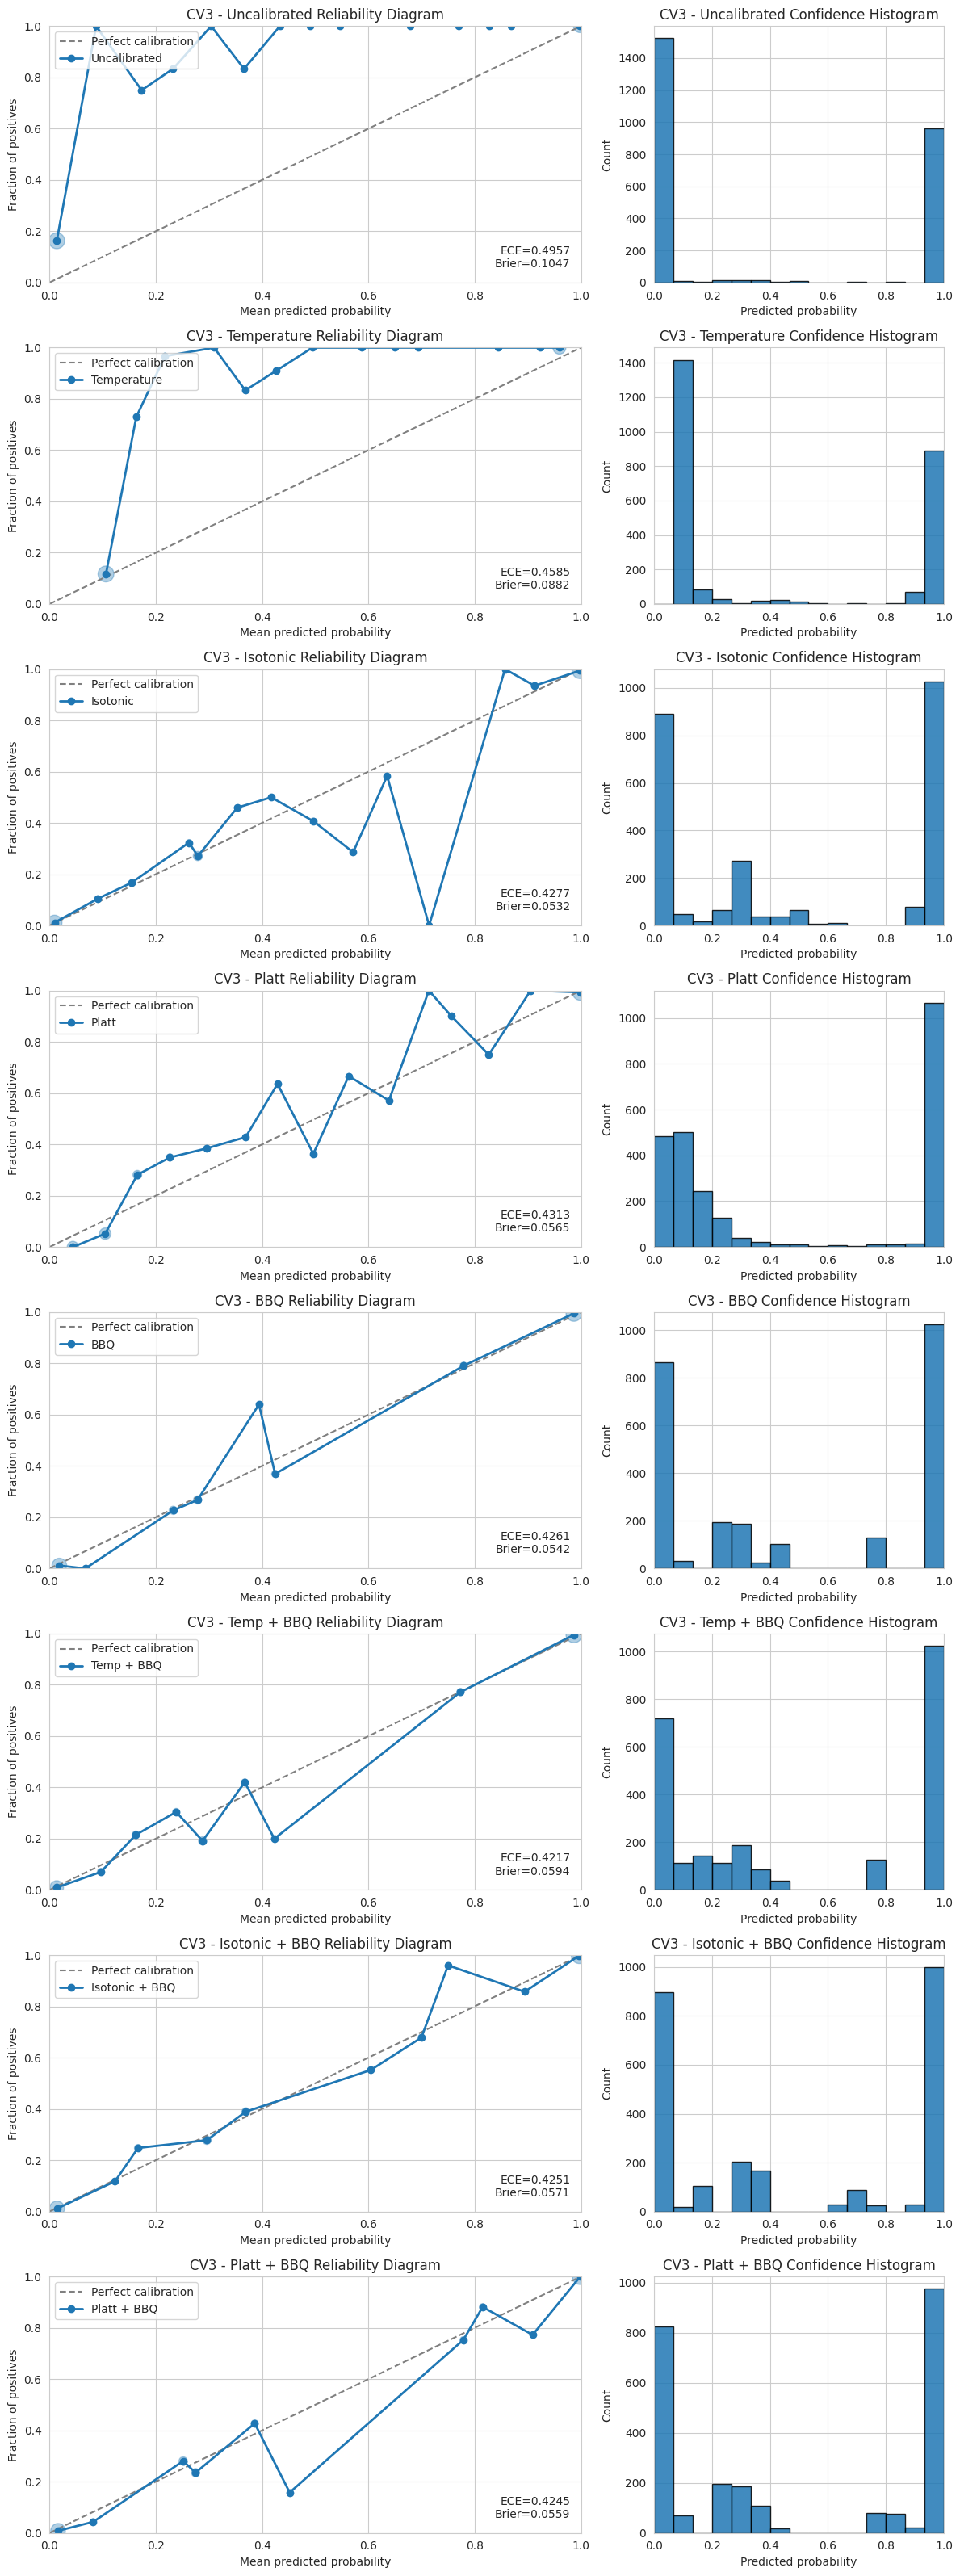

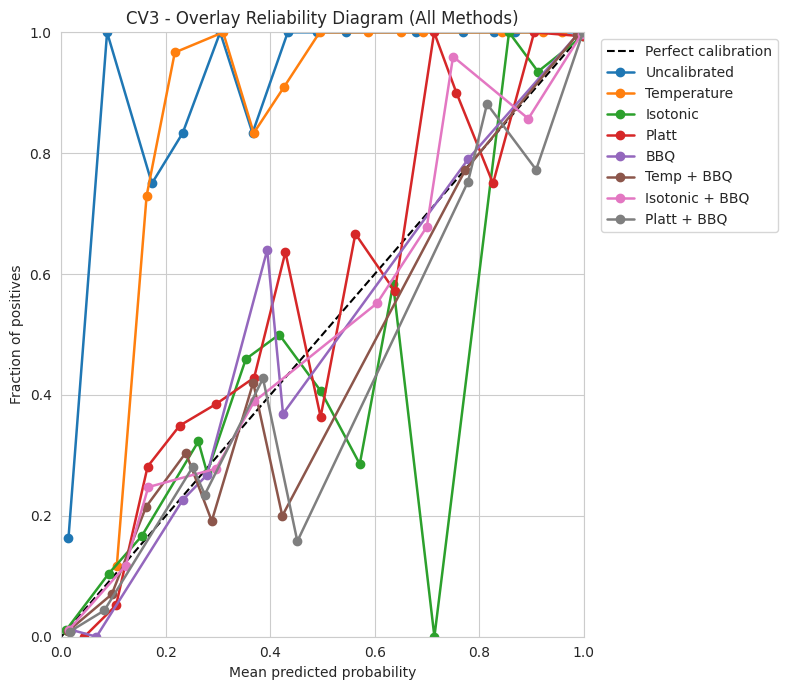

In [12]:
# ============================================
# Reliability Diagrams + Confidence Histograms
# Includes uncalibrated and all calibrated methods CV3
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add near top of cell
current_plot_fold = "CV3"   # change to CV2/CV3/CV4 when needed
sns.set_style("whitegrid")

# ---------- Helpers ----------
def calibration_curve_manual(y_true, y_prob, n_bins=15):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    prob_true = np.zeros(n_bins)
    prob_pred = np.zeros(n_bins)
    counts = np.zeros(n_bins, dtype=int)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            idx = (y_prob >= lo) & (y_prob < hi)
        else:
            idx = (y_prob >= lo) & (y_prob <= hi)

        counts[i] = np.sum(idx)
        if counts[i] > 0:
            prob_true[i] = np.mean(y_true[idx])
            prob_pred[i] = np.mean(y_prob[idx])
        else:
            prob_true[i] = np.nan
            prob_pred[i] = np.nan

    return bin_centers, prob_true, prob_pred, counts

def expected_calibration_error(y_true, y_prob, n_bins=15):
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        if i < n_bins - 1:
            idx = (y_prob >= lo) & (y_prob < hi)
        else:
            idx = (y_prob >= lo) & (y_prob <= hi)

        if np.any(idx):
            acc_bin = np.mean(y_true[idx] == (y_prob[idx] >= 0.5))
            conf_bin = np.mean(y_prob[idx])
            ece += np.sum(idx) * np.abs(acc_bin - conf_bin)
    return ece / len(y_true)

# ---------- Collect methods ----------
# These variables are expected from your prior calibration cell:
# y_val, calibrated_outputs (dict with keys below)

required_keys = [
    "uncalibrated",
    "temperature",
    "isotonic",
    "platt",
    "bbq",
    "temperature_bbq",
    "isotonic_bbq",
    "platt_bbq",
]
for k in required_keys:
    assert k in calibrated_outputs, f"Missing key in calibrated_outputs: {k}"

method_order = [
    ("uncalibrated",      "Uncalibrated"),
    ("temperature",       "Temperature"),
    ("isotonic",          "Isotonic"),
    ("platt",             "Platt"),
    ("bbq",               "BBQ"),
    ("temperature_bbq",   "Temp + BBQ"),
    ("isotonic_bbq",      "Isotonic + BBQ"),
    ("platt_bbq",         "Platt + BBQ"),
]

# ---------- Compute summary ----------
summary = []
for key, label in method_order:
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)
    ece = expected_calibration_error(y_val, p, n_bins=15)
    brier = np.mean((p - y_val) ** 2)
    summary.append((label, ece, brier))

summary = sorted(summary, key=lambda x: x[1])  # sort by ECE
print("=== Calibration summary (sorted by ECE) ===")
for label, ece, brier in summary:
    print(f"{label:16s} | ECE={ece:.4f} | Brier={brier:.4f}")

# ---------- Plot ----------
# 8 methods x (reliability + histogram) => 8 rows, 2 cols
fig, axes = plt.subplots(
    nrows=len(method_order), ncols=2,
    figsize=(12, 4 * len(method_order)),
    gridspec_kw={"width_ratios": [2.2, 1.2]}
)

if len(method_order) == 1:
    axes = np.array([axes])  # guard for shape consistency

for r, (key, label) in enumerate(method_order):
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)

    # Reliability diagram
    ax_rel = axes[r, 0]
    centers, prob_true, prob_pred, counts = calibration_curve_manual(y_val, p, n_bins=15)
    valid = ~np.isnan(prob_true)

    ax_rel.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.5, label="Perfect calibration")
    ax_rel.plot(prob_pred[valid], prob_true[valid], marker="o", linewidth=2, label=label)

    # Optional: visualize bin support as bubble size
    if np.any(valid):
        size = 20 + 180 * (counts[valid] / counts.max() if counts.max() > 0 else 1)
        ax_rel.scatter(prob_pred[valid], prob_true[valid], s=size, alpha=0.35)

    ece = expected_calibration_error(y_val, p, n_bins=15)
    brier = np.mean((p - y_val) ** 2)

    ax_rel.set_title(f"{current_plot_fold} - {label} Reliability Diagram")
    ax_rel.set_xlabel("Mean predicted probability")
    ax_rel.set_ylabel("Fraction of positives")
    ax_rel.set_xlim(0, 1)
    ax_rel.set_ylim(0, 1)
    ax_rel.legend(loc="upper left", frameon=True)
    ax_rel.text(
        0.98, 0.05, f"ECE={ece:.4f}\nBrier={brier:.4f}",
        transform=ax_rel.transAxes, ha="right", va="bottom",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    # Confidence histogram
    ax_hist = axes[r, 1]
    ax_hist.hist(p, bins=15, range=(0, 1), alpha=0.85, edgecolor="black")
    ax_hist.set_title(f"{current_plot_fold} - {label} Confidence Histogram")
    ax_hist.set_xlabel("Predicted probability")
    ax_hist.set_ylabel("Count")
    ax_hist.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# ---------- Optional: single combined overlay reliability plot ----------
plt.figure(figsize=(8, 7))
plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1.5, label="Perfect calibration")

for key, label in method_order:
    p = np.clip(calibrated_outputs[key], 1e-6, 1 - 1e-6)
    _, prob_true, prob_pred, _ = calibration_curve_manual(y_val, p, n_bins=15)
    valid = ~np.isnan(prob_true)
    plt.plot(prob_pred[valid], prob_true[valid], marker="o", linewidth=1.8, label=label)

plt.title(f"{current_plot_fold} - Overlay Reliability Diagram (All Methods)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()